# EDA — Contaminación del aire en la ZMVM: cuándo (meteorología diaria) y quién la respira (censo + satélite)

**Analítica Avanzada · Proyecto, entrega 1**

Este notebook une dos partes:

- **Lo que ya teníamos (EDA anterior):** el Censo 2020 por localidad, las estimaciones satelitales de PM2.5 y NO2 (2020) y los promedios de la RAMA por localidad, para las 5,085 localidades de la CDMX y el Estado de México.
- **Lo nuevo:** las bases **horarias** de contaminación (RAMA) y meteorología (REDMET) de 2015 a 2024. Agregan la dimensión de tiempo que no teníamos y sirven para validar el satélite.

Contenido:

1. Problemática a analizar
2. Variables de entrada propuestas
3. Posibles variables objetivo
4. Fuentes de datos exploradas
5. Datos seleccionados
6. Construcción de los datasets para exploración
7. Análisis estadístico básico de los datasets finales
8. Conclusiones

**Cómo correr este notebook.** En Google Colab: *Entorno de ejecución → Ejecutar todas*. Si en tu Drive está la carpeta del proyecto con `datos/`, la usa; si faltan los archivos horarios, los descarga del sitio de la SEDEMA (unos 120 MB, solo la primera vez). Los archivos del EDA anterior (`inegi_loc.csv`, `cont_loc_mean.csv`, los dos `.nc` del satélite y `municipios_cdmx_edomex.gpkg`) tienen que estar en `datos/`. En tu computadora basta con abrirlo desde la carpeta del proyecto. Todo tarda 2-3 minutos.

## 1. Problemática a analizar

La Zona Metropolitana del Valle de México (ZMVM) rebasa con mucha frecuencia los límites de calidad del aire. Los dos contaminantes que más afectan la salud y que más contingencias provocan son:

- **Ozono (O3):** no se emite directamente. Se forma cuando los óxidos de nitrógeno y los compuestos orgánicos de vehículos e industria reaccionan con la radiación solar, así que depende de la temperatura y la insolación.
- **Partículas finas (PM2.5):** vienen de la combustión (vehículos, incendios, quemas, pirotecnia). Se acumulan cuando el aire está estancado: poco viento y una inversión térmica.

En el EDA anterior estudiamos **dónde** está la contaminación y **quién** vive ahí (censo + satélite), pero solo con un promedio anual. No sabíamos **cuándo** ocurren los episodios ni qué los provoca, ni si el satélite es confiable. Ahora juntamos las dos dimensiones:

> **Pregunta 1 (tiempo):** ¿Qué tanto de la variación diaria de PM2.5 y ozono se explica por la meteorología (temperatura, humedad, viento, estabilidad del aire) y el calendario? ¿Se puede anticipar un día que rebase la norma con información disponible el día anterior?
>
> **Pregunta 2 (espacio y población):** ¿Qué población, y en particular qué población vulnerable, vive donde más días al año se rebasa la norma? ¿La exposición cambia con el nivel socioeconómico? ¿El satélite reproduce lo que miden las estaciones?

**Por qué importa:** si el clima explica una parte grande de la variación, un modelo de regresión puede anticipar los días críticos. Saber quién vive en las zonas con más días sobre la norma dice a quién dirigir esos avisos (escuelas, adultos mayores, personas sin seguridad social).

**Unidades de análisis:**

- **Día** (3,653 días, 2015-2024): dataset temporal para la pregunta 1.
- **Localidad** (5,085 localidades de la CDMX y el Estado de México, 26.2 millones de personas): dataset espacial para la pregunta 2.
- **Estación** (36 estaciones con datos 2015-2024): el puente entre los dos.

**Tipo de problema:** los objetivos principales son continuos (concentraciones y días sobre la norma) y se trabajan con los modelos de la unidad: regresión lineal, polinomial, robusta y redes neuronales. También hay objetivos binarios (¿se rebasó la norma?) para clasificación.

## 2. Variables de entrada propuestas

**Dataset diario (pregunta 1):**

| Grupo | Variable | Descripción | Por qué podría influir |
|---|---|---|---|
| Temperatura | `tmp_max` | Temperatura máxima del día (°C) | Más calor y sol aceleran la formación de ozono |
| Estabilidad | `amplitud_termica` | Máxima − mínima (°C) | Noches frías y días cálidos indican cielo despejado e inversiones térmicas |
| Humedad | `rh_prom` | Humedad relativa promedio (%) | Días húmedos o con lluvia limpian el aire y tienen menos sol |
| Viento | `wsp_prom`, `wsp_madrugada` | Velocidad promedio del día y de 01-08 h (m/s) | El viento dispersa; la calma de la madrugada favorece la acumulación |
| Dirección del viento | `viento_u`, `viento_v` | Componentes este-oeste y norte-sur (m/s) | Indican de dónde viene el aire |
| Calendario | `fin_semana`, `festivo` | Indicadores 0/1 | Cambian el tráfico; los festivos de diciembre traen pirotecnia |
| Estacionalidad | `dia_anio_sin`, `dia_anio_cos` | Posición del día en el año | Captan el ciclo anual sin un salto artificial entre diciembre y enero |
| Evento | `confinamiento` | 1 entre el 23 de marzo y el 30 de junio de 2020 | Caída de emisiones por la pandemia |
| Persistencia | `pm25_prom_ayer`, `o3_max1h_ayer` | Valor del contaminante el día anterior | Los episodios duran varios días |

**Dataset por localidad (pregunta 2), del EDA anterior:**

| Grupo | Variable | Descripción |
|---|---|---|
| Población | `POBTOT`, `POB0_14`, `POB65_MAS`, `PCON_DISC` | Población total y grupos vulnerables (Censo 2020) |
| Acceso a salud | `PSINDER`, `pct_sin_derechohab` | Personas sin derechohabiencia |
| Nivel socioeconómico | `GRAPROES`, `pct_viv_auto` | Escolaridad promedio y % de viviendas con automóvil |
| Ubicación | `lon`, `lat`, `ALTITUD` | Coordenadas y altitud de la localidad |
| Contaminación satelital | `pm25_sat`, `no2_sat` | Promedio anual 2020 (ACAG, ≈1.1 km) |
| Distancia a la red | `dist_est_o3_km`, `dist_est_pm25_km` | Distancia a la estación RAMA más cercana (nuevo) |

## 3. Posibles variables objetivo

| Variable | Dataset | Qué mide | Uso |
|---|---|---|---|
| **`pm25_prom`** | Diario | PM2.5 promedio de 24 h, promediado entre estaciones (µg/m³) | **Objetivo principal** (regresión) |
| **`o3_max1h`** | Diario | Ozono máximo horario en cualquier estación (ppb), el valor con el que se evalúa la NOM | **Objetivo principal** (regresión) |
| `o3_8h_max`, `pm25_max_est` | Diario | Ozono móvil de 8 h; PM2.5 de la estación más alta | Alternativos |
| `excede_pm25`, `excede_o3` | Diario | 1 si alguna estación rebasó 41 µg/m³ de PM2.5 (24 h) o 90 ppb de ozono (1 h) | Clasificación |
| **`o3_dias_sobre_nom`** | Localidad | Días al año con ozono > 90 ppb en la estación más cercana (≤ 5 km) | **Objetivo espacial** |
| `pm25_dias_sobre_nom` | Localidad | Días al año con PM2.5 > 41 µg/m³ en la estación más cercana (≤ 5 km) | Objetivo espacial |
| `pm25_sat`, `no2_sat` | Localidad | Contaminación satelital anual | Objetivo espacial con cobertura total |

Para los objetivos binarios se usa el límite de 2022-2023 (41 µg/m³) en todos los años para poder compararlos. La norma bajó a 33 µg/m³ en 2024-2025 y bajará a 25 µg/m³ en 2026.

## 4. Fuentes de datos exploradas

| # | Fuente | Institución | Qué contiene | ¿La usamos? |
|---|---|---|---|---|
| 1 | **RAMA, bases horarias anuales** (nuevo) | SEDEMA CDMX (SIMAT) | O3, NO2, NO, NOx, CO, SO2, PM10, PM2.5 y PMCO cada hora en ~40 estaciones, desde 1986 | **Sí.** Objetivos diarios y días sobre la norma por estación |
| 2 | **REDMET, bases horarias anuales** (nuevo) | SEDEMA CDMX (SIMAT) | Temperatura, humedad y viento cada hora en ~28 estaciones | **Sí.** Entradas del dataset diario |
| 3 | **Catálogo de estaciones del SIMAT** (nuevo) | SEDEMA CDMX | Coordenadas y altitud de cada estación | **Sí.** Une estaciones con localidades |
| 4 | **Censo de Población y Vivienda 2020, ITER** (EDA anterior) | INEGI | 232 variables para 5,085 localidades | **Sí.** Población y vulnerabilidad |
| 5 | **Satélite ACAG: PM2.5 V6.GL.02.04 y NO2 V4.GL.01** (EDA anterior) | Washington University | Rásteres de ≈1.1 km, 2020 | **Sí.** Cobertura total; se valida con la RAMA |
| 6 | **Promedios de la RAMA por localidad** (`cont_loc_mean.csv`, EDA anterior) | SEDEMA CDMX | Promedio por contaminante para 494 localidades de la CDMX | **Sí**, como referencia |
| 7 | **Marco Geoestadístico 2020** (EDA anterior) | INEGI | Polígonos de municipios | Sí, para los mapas |
| 8 | Egresos hospitalarios (SAEH) 2008-2024 | Secretaría de Salud | Hospitalizaciones por diagnóstico y municipio | **Revisada y descartada.** Las hospitalizaciones respiratorias seguían el mismo patrón que las de lesiones (ρ = 0.80): medían acceso al hospital, no el efecto del aire |
| 9 | Inventario de Emisiones de la ZMVM 2020 | SEDEMA CDMX | Toneladas por tipo de fuente | Revisada. Es anual y por entidad |
| 10 | ERA5 / Open-Meteo (reanálisis meteorológico) | Copernicus / Open-Meteo | Altura de capa de mezcla, radiación, lluvia por hora | Revisada. Propuesta para la siguiente entrega |

**Enlaces:** [Bases horarias de contaminantes](https://aire.cdmx.gob.mx/default.php?opc='aKBhnmI='&opcion=Zg==) · [Bases horarias de meteorología](https://aire.cdmx.gob.mx/default.php?opc='aKBhnmI='&opcion=Zw==) · [Normatividad](https://aire.cdmx.gob.mx/default.php?opc=%27ZaBhnmI=&dc=%27Yw==) · [Censo 2020](https://www.inegi.org.mx/programas/ccpv/2020/) · [Satélite PM2.5 ACAG](https://sites.wustl.edu/acag/datasets/surface-pm2-5/) · [Satélite NO2 ACAG](https://sites.wustl.edu/acag/datasets/sat-no2/) · [Inventario de emisiones 2020](https://proyectos.sedema.cdmx.gob.mx/datos/storage/app/media/docpub/sedema/inventario-emisiones-cdmx-2020bis.pdf)

## 5. Datos seleccionados

| Datos | Periodo | Tamaño | Para qué |
|---|---|---|---|
| RAMA + REDMET horarios (nuevo) | 2015-2024 | 20 archivos, 24.8 millones de registros | Dataset diario y resumen por estación |
| Censo 2020 por localidad (EDA anterior) | 2020 | 5,085 localidades | Dataset por localidad |
| Satélite PM2.5 y NO2 (EDA anterior) | 2020 | 2 rásteres recortados a la ZMVM | Contaminación en cada localidad |
| `cont_loc_mean.csv` (EDA anterior) | — | 494 localidades | Referencia |

**Cómo se unen:** la estación es el puente. Cada estación tiene coordenadas, así que se le asigna el valor del satélite de su celda (para validarlo) y cada localidad del censo recibe su estación más cercana (si está a 5 km o menos).

**Por qué la RAMA horaria:** es la única fuente con variación día a día. Son mediciones directas, y diez años dan 3,653 observaciones, suficientes para separar entrenamiento y prueba por tiempo. En 2015 ya operaba la red actual de PM2.5 y 2024 es el último año completo.

**Por qué conservar el satélite y el censo:** las estaciones solo cubren el centro de la ZMVM. El satélite cubre las 5,085 localidades, y el censo dice quién vive en cada una.

**Problema detectado (sección 6.2):** en 2024 la velocidad del viento se duplica en todas las estaciones y en todos los meses, aunque el archivo declara la misma unidad. Es un cambio de escala no documentado, así que el viento de 2024 se marca como faltante.

## 6. Construcción de los datasets para exploración

**Parte A — Dataset diario (datos nuevos de la RAMA y la REDMET)**

### 6.0 Entorno y librerías

In [1]:
# Preparación del entorno: funciona en Google Colab y en local (VS Code / Jupyter)
import os, sys, io, gzip, subprocess
from pathlib import Path

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

def es_proyecto(p):
    return (p / "datos").is_dir() and ((p / "datos" / "rama").is_dir() or (p / "datos" / "dataset_final_diario.csv").exists())

if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Busca en tu Drive la carpeta del proyecto (la que contiene datos/rama o datos/dataset_final_diario.csv)
    candidatos = sorted({p.parent.parent for patron in ["datos/rama/cat_estacion.csv", "datos/dataset_final_diario.csv"]
                         for p in Path("/content/drive/MyDrive").rglob(patron)}, key=lambda p: len(str(p)))
    if candidatos:
        os.chdir(candidatos[0])
    else:
        # Sin carpeta en Drive: se trabaja en /content y los datos se descargan del sitio de la SEDEMA
        Path("/content/proyecto/datos").mkdir(parents=True, exist_ok=True)
        os.chdir("/content/proyecto")
elif not es_proyecto(Path.cwd()):
    for p in [Path.cwd().parent, Path.home() / "Documents/2027-1/Analitica_avanzada"]:
        if es_proyecto(p):
            os.chdir(p)
            break

print("Entorno:", "Colab" if EN_COLAB else "local", "| Carpeta del proyecto:", Path.cwd())

Entorno: local | Carpeta del proyecto: /Users/sayuriherreramoreno/Documents/2027-1/Analitica_avanzada


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy import stats
from dateutil.easter import easter
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATOS = Path("datos")
RAMA = DATOS / "rama"            # archivos horarios originales (uno por año)
FIGURAS = Path("figuras_rama")   # figuras para el reporte
RAMA.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(exist_ok=True)

def guardar(fig, nombre):
    fig.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", dpi=150)

AÑOS = list(range(2015, 2025))   # 10 años completos

# Límites de la normatividad mexicana (NOM-025-SSA1-2021 y NOM-020-SSA1-2021)
NOM_PM25_24H = 41    # µg/m³, promedio de 24 h (valor 2022-2023; en 2024-2025 bajó a 33)
NOM_O3_1H = 90       # ppb, promedio horario
OMS_PM25_24H = 15    # µg/m³, guía OMS 2021

COLOR = {"PM2.5": "#2a78d6", "O3": "#eb6834", "gris": "#7f7f7f"}

### 6.1 Descarga de los archivos horarios

Se descarga un archivo de contaminantes y uno de meteorología por año desde el portal de datos abiertos de la SEDEMA. Si ya están en `datos/rama/`, no se vuelven a descargar.

In [3]:
URL_BASE = "https://aire.cdmx.gob.mx/descargas/Opendata"
ARCHIVOS = {
    "cat_estacion.csv": f"{URL_BASE}/Bases_publicas/Data%20Set/catalogos/cat_estacion.csv",
    **{f"contaminantes_{a}.csv.gz": f"{URL_BASE}/anuales_horarios_gz/contaminantes_{a}.csv.gz" for a in AÑOS},
    # la meteorología solo se publica sin comprimir; se guarda comprimida para ahorrar espacio
    **{f"meteorologia_{a}.csv.gz": f"{URL_BASE}/anuales_horarios/meteorolog%C3%ADa_{a}.csv" for a in AÑOS},
}

def descargar(nombre, url):
    destino = RAMA / nombre
    if destino.exists():
        return "ya existe"
    r = requests.get(url, timeout=600, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    contenido = r.content
    if nombre.endswith(".gz") and not url.endswith(".gz"):
        contenido = gzip.compress(contenido)
    destino.write_bytes(contenido)
    return f"descargado ({len(contenido) / 1e6:.1f} MB)"

# Solo se descargan los archivos que falten (la primera vez en Colab tarda 2-5 minutos)
for nombre, url in ARCHIVOS.items():
    try:
        estado = descargar(nombre, url)
    except requests.RequestException as e:
        estado = f"FALLÓ ({e.__class__.__name__}). Súbelo a mano a {RAMA}"
    if estado != "ya existe":
        print(nombre, "→", estado)
faltan = [n for n in ARCHIVOS if not (RAMA / n).exists()]
if faltan:
    raise FileNotFoundError(f"Faltan {len(faltan)} archivos en {RAMA}: {faltan}. Descárgalos de "
                            "https://aire.cdmx.gob.mx/default.php?opc='aKBhnmI='&opcion=Zg== (contaminantes) y "
                            "https://aire.cdmx.gob.mx/default.php?opc='aKBhnmI='&opcion=Zw== (meteorología)")

presentes = sorted(p.name for p in RAMA.glob("*"))
print(f"\n{len(presentes)} archivos en {RAMA}:")
print(pd.Series({p: f"{(RAMA / p).stat().st_size / 1e6:.1f} MB" for p in presentes}).to_string())


21 archivos en datos/rama:
cat_estacion.csv             0.0 MB
contaminantes_2015.csv.gz    7.4 MB
contaminantes_2016.csv.gz    7.8 MB
contaminantes_2017.csv.gz    7.8 MB
contaminantes_2018.csv.gz    7.7 MB
contaminantes_2019.csv.gz    8.1 MB
contaminantes_2020.csv.gz    7.9 MB
contaminantes_2021.csv.gz    7.9 MB
contaminantes_2022.csv.gz    9.1 MB
contaminantes_2023.csv.gz    8.6 MB
contaminantes_2024.csv.gz    9.1 MB
meteorologia_2015.csv.gz     3.4 MB
meteorologia_2016.csv.gz     4.0 MB
meteorologia_2017.csv.gz     4.0 MB
meteorologia_2018.csv.gz     4.0 MB
meteorologia_2019.csv.gz     4.1 MB
meteorologia_2020.csv.gz     4.1 MB
meteorologia_2021.csv.gz     4.0 MB
meteorologia_2022.csv.gz     4.5 MB
meteorologia_2023.csv.gz     4.4 MB
meteorologia_2024.csv.gz     4.1 MB


### 6.2 Lectura y calidad de los datos horarios

El SIMAT **cambió el formato en 2022**, y el código maneja los dos:

| | 2015-2021 | 2022-2024 |
|---|---|---|
| Compresión | gzip | zip (con extensión `.gz`) |
| Líneas de metadatos | 10 | 9 |
| Fecha | `dd/mm/aaaa HH:MM`, horas 01 a 24 | `aaaa-mm-dd HH:MM:SS`; la hora 24 aparece como 00:00 del día siguiente |

La hora indica el **final** del promedio horario. Por eso se resta una hora para asignar cada medición a su día.

In [4]:
import zipfile

def abrir(ruta):
    """El SIMAT cambió de formato en 2022: hasta 2021 los .gz son gzip; desde 2022 son .zip con otro nombre."""
    with open(ruta, "rb") as f:
        firma = f.read(2)
    if firma == b"PK":
        z = zipfile.ZipFile(ruta)
        return io.BytesIO(z.read(z.namelist()[0]))
    return io.BytesIO(gzip.decompress(Path(ruta).read_bytes()))

def leer_horario(ruta, año):
    """Lee un archivo anual del SIMAT y devuelve fecha + hora (1 a 24) de cada medición.

    - Las primeras 9 o 10 líneas son metadatos; se busca la línea que empieza con 'date'.
    - La hora marca el FINAL del promedio horario. Hasta 2021 viene como 'dd/mm/aaaa 01:00 ... 24:00';
      desde 2022 como 'aaaa-mm-dd 01:00:00 ... 23:00:00' y la hora 24 aparece como 00:00 del día siguiente.
      Restando una hora al final del intervalo, los dos formatos quedan iguales."""
    buf = abrir(ruta)
    cabecera = next(i for i, l in enumerate(buf.read(3000).decode("latin-1").splitlines())
                    if l.replace('"', "").startswith("date"))
    buf.seek(0)
    df = pd.read_csv(buf, skiprows=cabecera, encoding="latin-1",
                     usecols=["date", "id_station", "id_parameter", "value"],
                     dtype={"id_station": "category", "id_parameter": "category", "value": "float64"})
    txt = df["date"].astype(str)
    if txt.iloc[0][2] == "/":   # formato viejo dd/mm/aaaa HH:MM, con HH de 01 a 24
        fin = pd.to_datetime(txt.str[:10], format="%d/%m/%Y") + pd.to_timedelta(txt.str[11:13].astype(int), unit="h")
    else:                       # formato nuevo ISO
        fin = pd.to_datetime(txt, format="ISO8601", errors="coerce")
    df, fin = df[fin.notna()], fin[fin.notna()]          # descarta fechas ilegibles (si las hay)
    inicio = fin - pd.Timedelta(hours=1)
    df["fecha"] = inicio.dt.normalize()
    df["hora"] = (inicio.dt.hour + 1).astype("int8")
    return df.loc[df.fecha.dt.year == año].drop(columns="date")

muestra = leer_horario(RAMA / "contaminantes_2019.csv.gz", 2019)
print("Ejemplo: contaminantes 2019 →", muestra.shape)
display(muestra.head())
display(muestra.groupby("id_parameter", observed=True)["value"]
              .agg(registros="size", con_valor="count", minimo="min", mediana="median", maximo="max")
              .assign(pct_faltante=lambda t: (1 - t.con_valor / t.registros) * 100).round(2))

Ejemplo: contaminantes 2019 → (2266536, 5)


,id_station,id_parameter,value,fecha,hora
0,ACO,CO,NaN,2019-01-01,1
1,ACO,NO,NaN,2019-01-01,1
2,ACO,NO2,NaN,2019-01-01,1
3,ACO,NOX,NaN,2019-01-01,1
4,ACO,O3,NaN,2019-01-01,1


,registros,con_valor,minimo,mediana,maximo,pct_faltante
id_parameter,,,,,,
CO,277488,200825,0.0,0.3,5.2,27.63
NO,268728,182922,0.0,3.0,456.0,31.93
NO2,295008,212201,0.0,19.0,109.0,28.07
NOX,268728,182922,0.0,25.0,509.0,31.93
O3,312528,246838,0.0,25.0,159.0,21.02
PM10,219000,146818,1.0,38.0,653.0,32.96
PM2.5,207408,127224,1.0,20.0,393.0,38.66
PMCO,131400,82989,1.0,17.0,294.0,36.84
SO2,286248,213932,0.0,1.0,219.0,25.26


In [5]:
# Calidad de los datos horarios: faltantes por año y valores fuera de rango físico
RANGOS = {"PM2.5": (0, 1000), "PM10": (0, 1500), "O3": (0, 400), "NO2": (0, 500), "CO": (0, 50),
          "SO2": (0, 1000), "TMP": (-15, 45), "RH": (0, 100), "WSP": (0, 40), "WDR": (0, 360)}
PARAM_CONT = ["PM2.5", "PM10", "O3", "NO2", "CO", "SO2"]
PARAM_MET = ["TMP", "RH", "WSP", "WDR"]

def limpiar(df):
    """Quita parámetros que no se usan y marca como faltante lo que está fuera de rango."""
    df = df[df.id_parameter.isin(RANGOS)].copy()
    df["id_parameter"] = df.id_parameter.astype(str)
    lo = df.id_parameter.map(lambda p: RANGOS[p][0])
    hi = df.id_parameter.map(lambda p: RANGOS[p][1])
    fuera = df.value.notna() & ((df.value < lo) | (df.value > hi))
    df.loc[fuera, "value"] = np.nan
    return df, int(fuera.sum())

resumen_calidad = []
horario = {}
for a in AÑOS:
    c, fc = limpiar(leer_horario(RAMA / f"contaminantes_{a}.csv.gz", a))
    m, fm = limpiar(leer_horario(RAMA / f"meteorologia_{a}.csv.gz", a))
    horario[a] = pd.concat([c, m], ignore_index=True)
    for p, g in horario[a].groupby("id_parameter"):
        resumen_calidad.append({"año": a, "parametro": p, "registros": len(g),
                                "pct_faltante": g.value.isna().mean() * 100,
                                "estaciones": g.id_station.nunique()})
    print(a, "| registros:", f"{len(horario[a]):,}", "| fuera de rango:", fc + fm)

# Revisión de consistencia entre años: promedio anual de cada variable meteorológica
consistencia = pd.DataFrame({a: df[df.id_parameter.isin(["TMP", "RH", "WSP"])].groupby("id_parameter").value.mean()
                             for a, df in horario.items()}).round(2)
print("\nPromedio anual de las variables meteorológicas (todas las estaciones)")
display(consistencia)

# En 2024 la velocidad del viento se duplica en TODAS las estaciones y en todos los meses, sin cambio de unidad
# declarado en el archivo. Es un cambio de escala no documentado, no un cambio real del clima, así que el viento
# de 2024 (velocidad y dirección) se marca como faltante.
AÑOS_VIENTO_INVALIDO = [2024]
for a in AÑOS_VIENTO_INVALIDO:
    h = horario[a]
    h.loc[h.id_parameter.isin(["WSP", "WDR"]), "value"] = np.nan

calidad = pd.DataFrame(resumen_calidad)
tabla_faltantes = calidad.pivot(index="parametro", columns="año", values="pct_faltante").round(1)
tabla_estaciones = calidad.pivot(index="parametro", columns="año", values="estaciones")
print("\n% de horas sin dato por parámetro y año")
display(tabla_faltantes)
print("Número de estaciones que reportan cada parámetro")
display(tabla_estaciones)

2015 | registros: 2,122,848 | fuera de rango: 0
2016 | registros: 2,393,808 | fuera de rango: 0
2017 | registros: 2,400,240 | fuera de rango: 0
2018 | registros: 2,400,240 | fuera de rango: 0
2019 | registros: 2,538,096 | fuera de rango: 0
2020 | registros: 2,564,928 | fuera de rango: 5
2021 | registros: 2,565,264 | fuera de rango: 0
2022 | registros: 2,576,058 | fuera de rango: 5
2023 | registros: 2,557,808 | fuera de rango: 13
2024 | registros: 2,650,162 | fuera de rango: 0

Promedio anual de las variables meteorológicas (todas las estaciones)


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
id_parameter,,,,,,,,,,
RH,62.70,58.03,54.03,57.22,53.20,52.03,54.17,53.29,51.99,51.70
TMP,16.40,16.28,16.49,16.34,17.14,17.01,16.51,16.85,16.99,17.25
WSP,2.03,2.12,2.09,1.99,2.11,2.23,2.07,2.11,2.08,4.40



% de horas sin dato por parámetro y año


año,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
parametro,,,,,,,,,,
CO,20.9,19.7,18.0,18.8,27.6,31.2,31.3,32.0,28.7,36.5
NO2,26.8,25.6,29.0,28.0,28.1,34.3,34.9,36.6,35.1,42.1
O3,16.1,14.2,15.5,21.2,21.0,31.5,31.1,26.6,25.3,29.3
PM10,18.0,19.3,29.4,34.9,33.0,45.6,41.1,41.7,43.8,49.1
PM2.5,15.9,28.2,33.3,38.3,38.7,44.2,44.7,44.0,41.6,47.0
RH,8.3,7.2,6.3,16.1,16.8,18.2,18.5,14.5,21.0,37.4
SO2,20.1,19.0,14.7,18.8,25.3,31.4,34.6,31.6,33.5,36.8
TMP,9.1,7.9,9.5,16.5,13.2,14.4,21.3,21.1,23.9,49.0
WDR,8.6,9.7,10.1,11.8,7.6,13.7,21.7,15.8,18.5,41.9


Número de estaciones que reportan cada parámetro


año,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
parametro,,,,,,,,,,
CO,30,30,30,30,32,32,32,33,32,33
NO2,31,29,29,29,34,34,34,36,34,36
O3,35,34,34,34,36,36,36,36,34,36
PM10,24,24,25,25,25,25,26,28,26,28
PM2.5,20,21,21,21,24,24,24,24,22,24
RH,24,26,26,26,26,26,26,28,28,28
SO2,32,31,31,31,33,33,33,33,32,33
TMP,24,26,26,26,26,26,26,28,28,28
WDR,26,26,26,26,28,28,28,28,28,28


**Lo que muestra la calidad de los datos:**

- Casi no hay valores fuera del rango físico: solo 23 registros en diez años (2020, 2022 y 2023), que se marcan como faltantes.
- **La proporción de horas sin dato creció con los años.** En PM2.5 pasó de 16% en 2015 a 44-47% en 2020-2024; en PM10, de 18% a 49%. No significa que haya menos información: entraron estaciones nuevas que no reportan todos los parámetros, y el número de estaciones con PM2.5 subió de 20 a 24.
- Por eso no se analizan estaciones aisladas. Se calcula un promedio diario por estación y luego se combinan las estaciones disponibles cada día (secciones 6.3 y 6.4).
- **El viento de 2024 es inconsistente:** promedia 4.4 m/s contra 2.0-2.2 m/s en todos los años anteriores, en todas las estaciones y en todos los meses. La temperatura y la humedad de 2024 sí son consistentes. El viento de 2024 se marca como faltante.

### 6.3 Promedios diarios por estación

Para cada estación, día y parámetro se calcula el promedio, el máximo horario y el número de horas con dato. Siguiendo el criterio de suficiencia del SIMAT, **el promedio diario solo es válido si hay al menos 18 horas (75%)**.

Para el ozono también se calcula el máximo del promedio móvil de 8 horas, que es el segundo indicador de la NOM-020. Para el viento se promedian los vectores (componentes u y v), no los grados: un promedio simple entre 350° y 10° daría 180°, que es la dirección contraria.

In [6]:
MIN_HORAS = 18   # criterio de suficiencia: un promedio diario es válido con al menos 75% de las horas

def diario_por_estacion(df):
    """Un renglón por estación y día con promedio, máximo y número de horas válidas de cada parámetro."""
    g = df.dropna(subset=["value"]).groupby(["fecha", "id_station", "id_parameter"], observed=True).value
    d = g.agg(prom="mean", maxh="max", horas="count").reset_index()
    d.loc[d.horas < MIN_HORAS, "prom"] = np.nan      # día incompleto: no se usa el promedio
    return d

def o3_8h_max(df):
    """Máximo diario del promedio móvil de 8 horas de ozono (como lo pide la NOM-020)."""
    o3 = df[df.id_parameter == "O3"].copy()
    o3["ts"] = o3.fecha + pd.to_timedelta(o3.hora.astype(int), unit="h")
    o3 = o3.sort_values(["id_station", "ts"])
    o3["m8"] = (o3.groupby("id_station", observed=True).value
                  .transform(lambda s: s.rolling(8, min_periods=6).mean()))
    return (o3.groupby(["fecha", "id_station"], observed=True).m8.max()
              .rename("o3_8h").reset_index())

def viento_vectorial(df):
    """Componentes u (este-oeste) y v (norte-sur) del viento, promediadas por día.
    La dirección es de dónde viene el viento (convención meteorológica)."""
    w = df[df.id_parameter.isin(["WSP", "WDR"])].dropna(subset=["value"])
    if w.empty:                      # año sin viento válido
        return pd.DataFrame({"fecha": pd.Series(dtype="datetime64[us]"), "id_station": pd.Series(dtype=str),
                             "u": pd.Series(dtype=float), "v": pd.Series(dtype=float)})
    w = (w.pivot_table(index=["fecha", "hora", "id_station"], columns="id_parameter", values="value", observed=True)
           .dropna())
    rad = np.deg2rad(w.WDR)
    w["u"] = -w.WSP * np.sin(rad)
    w["v"] = -w.WSP * np.cos(rad)
    return w.groupby(level=["fecha", "id_station"])[["u", "v"]].mean().reset_index()

partes, partes_o3, partes_viento, perfil = [], [], [], []
for a, df in horario.items():
    partes.append(diario_por_estacion(df))
    partes_o3.append(o3_8h_max(df))
    partes_viento.append(viento_vectorial(df))
    # perfil por hora del día (promedio de todas las estaciones), para el análisis del ciclo diario
    perfil.append(df[df.id_parameter.isin(PARAM_CONT + ["TMP", "WSP"])]
                    .groupby(["id_parameter", "hora"]).value.mean().rename(a))

est_dia = pd.concat(partes, ignore_index=True)
o3_8h = pd.concat(partes_o3, ignore_index=True)
viento = pd.concat(partes_viento, ignore_index=True)
perfil_horario = pd.concat(perfil, axis=1).mean(axis=1).unstack(0)

print("Renglones estación-día-parámetro:", f"{len(est_dia):,}")
print("Días con promedio válido (≥18 h):", f"{est_dia.prom.notna().mean() * 100:.1f}%")
display(est_dia.head())

Renglones estación-día-parámetro: 787,391
Días con promedio válido (≥18 h): 97.5%


,fecha,id_station,id_parameter,prom,maxh,horas
0,2015-01-01,ACO,CO,0.579167,1.2,24
1,2015-01-01,ACO,NO2,14.041667,29.0,24
2,2015-01-01,ACO,O3,21.208333,54.0,24
3,2015-01-01,ACO,PM10,75.708333,181.0,24
4,2015-01-01,ACO,RH,64.458333,96.0,24


### 6.4 Un renglón por día para toda la zona metropolitana

- **PM2.5, PM10, NO2, CO y SO2:** promedio de las estaciones con dato válido (exposición típica de la población). Para PM2.5 se guarda también la estación más alta.
- **Ozono:** máximo horario en cualquier estación, que es como se evalúa la norma y se activan las contingencias.
- **Meteorología:** promedio de las estaciones.

In [7]:
# Pasamos de estación-día a un solo renglón por día para toda la zona metropolitana
ancho = est_dia.pivot_table(index=["fecha", "id_station"], columns="id_parameter", values=["prom", "maxh"], observed=True)
ancho.columns = [f"{p}_{e}" for e, p in ancho.columns]
ancho = (ancho.reset_index()
              .merge(o3_8h, on=["fecha", "id_station"], how="left")
              .merge(viento, on=["fecha", "id_station"], how="left"))

agg = {
    # contaminantes: promedio entre estaciones (exposición típica) y máximo (peor estación)
    "pm25_prom": ("PM2.5_prom", "mean"), "pm25_max_est": ("PM2.5_prom", "max"), "n_est_pm25": ("PM2.5_prom", "count"),
    "pm10_prom": ("PM10_prom", "mean"),
    "no2_prom": ("NO2_prom", "mean"),
    "co_prom": ("CO_prom", "mean"),
    "so2_prom": ("SO2_prom", "mean"),
    "o3_max1h": ("O3_maxh", "max"), "o3_max1h_prom": ("O3_maxh", "mean"), "n_est_o3": ("O3_maxh", "count"),
    "o3_8h_max": ("o3_8h", "max"),
    # meteorología: promedio entre estaciones
    "tmp_prom": ("TMP_prom", "mean"), "tmp_max": ("TMP_maxh", "mean"),
    "rh_prom": ("RH_prom", "mean"),
    "wsp_prom": ("WSP_prom", "mean"), "wsp_max": ("WSP_maxh", "mean"),
    "viento_u": ("u", "mean"), "viento_v": ("v", "mean"),
}
dia = ancho.groupby("fecha").agg(**agg)

# Temperatura mínima: mínimo horario de cada estación, promediado entre estaciones
tmin = pd.concat([df[df.id_parameter == "TMP"].groupby(["fecha", "id_station"], observed=True).value.min()
                  for df in horario.values()])
dia["tmp_min"] = tmin.groupby(level="fecha").mean()
dia["amplitud_termica"] = dia.tmp_max - dia.tmp_min

# Viento en la madrugada (01-08 h): con poco viento los contaminantes se acumulan
madrugada = pd.concat([df[(df.id_parameter == "WSP") & df.hora.between(1, 8)].groupby("fecha").value.mean()
                       for df in horario.values()])
dia["wsp_madrugada"] = madrugada

# Calendario completo: aseguramos que no falte ningún día
dia = dia.reindex(pd.date_range(f"{AÑOS[0]}-01-01", f"{AÑOS[-1]}-12-31", freq="D")).rename_axis("fecha").reset_index()
print("Días:", len(dia))
display(dia.describe().T.round(2))

Días: 3653


,count,mean,min,25%,50%,75%,max,std
fecha,3653,2020-01-01 00:00:00,2015-01-01 00:00:00,2017-07-02 00:00:00,2020-01-01 00:00:00,2022-07-02 00:00:00,2024-12-31 00:00:00,NaN
pm25_prom,3653.0,20.918181,2.928541,14.985354,20.111604,25.78442,86.904903,8.697008
pm25_max_est,3653.0,28.852658,4.545455,20.565217,27.545455,35.142857,132.375,12.409113
n_est_pm25,3653.0,13.667123,3.0,13.0,14.0,15.0,19.0,2.006781
pm10_prom,3653.0,41.348155,8.573613,29.013029,39.716764,51.886016,115.797722,15.879036
no2_prom,3652.0,22.928849,7.6625,18.160575,22.26318,26.717184,72.193452,6.699452
co_prom,3652.0,0.477436,0.124735,0.3289,0.439449,0.590277,1.83183,0.198624
so2_prom,3653.0,3.554688,0.605993,1.495508,2.397582,4.25463,31.512112,3.361296
o3_max1h,3653.0,100.530523,22.0,83.0,102.0,119.0,210.0,27.669046
o3_max1h_prom,3653.0,74.618414,8.84,61.4,75.653846,88.5,143.217391,20.509124


### 6.5 Variables derivadas: calendario, temporada, rezagos y objetivos binarios

In [8]:
def festivos(año):
    """Días de descanso obligatorio (LFT) más jueves y viernes santos."""
    def lunes(mes, n):
        d = pd.Timestamp(año, mes, 1)
        d += pd.Timedelta(days=(7 - d.weekday()) % 7)
        return d + pd.Timedelta(weeks=n - 1)
    pascua = pd.Timestamp(easter(año))
    return {pd.Timestamp(año, 1, 1), lunes(2, 1), lunes(3, 3), pd.Timestamp(año, 5, 1), pd.Timestamp(año, 9, 16),
            lunes(11, 3), pd.Timestamp(año, 12, 25), pascua - pd.Timedelta(days=3), pascua - pd.Timedelta(days=2)}

FESTIVOS = set().union(*[festivos(a) for a in AÑOS])

def temporada(mes):
    if mes in (11, 12, 1, 2):
        return "Seca fría"
    if mes in (3, 4, 5):
        return "Seca caliente"
    return "Lluvias"

dia["año"] = dia.fecha.dt.year
dia["mes"] = dia.fecha.dt.month
dia["dia_semana"] = dia.fecha.dt.dayofweek          # 0 = lunes
dia["fin_semana"] = (dia.dia_semana >= 5).astype(int)
dia["festivo"] = dia.fecha.isin(FESTIVOS).astype(int)
dia["temporada"] = dia.mes.map(temporada)
# Confinamiento por COVID-19: Jornada Nacional de Sana Distancia y semáforo rojo en la ZMVM
dia["confinamiento"] = dia.fecha.between("2020-03-23", "2020-06-30").astype(int)
dia["dia_anio_sin"] = np.sin(2 * np.pi * dia.fecha.dt.dayofyear / 365.25)
dia["dia_anio_cos"] = np.cos(2 * np.pi * dia.fecha.dt.dayofyear / 365.25)

# Rezagos: la contaminación de ayer es información disponible hoy (persistencia)
dia = dia.sort_values("fecha")
for col in ["pm25_prom", "o3_max1h", "wsp_prom", "tmp_max"]:
    dia[f"{col}_ayer"] = dia[col].shift(1)

# Variables objetivo binarias (días que rebasan la norma)
dia["excede_pm25"] = np.where(dia.pm25_max_est.notna(), (dia.pm25_max_est > NOM_PM25_24H).astype(float), np.nan)
dia["excede_o3"] = np.where(dia.o3_max1h.notna(), (dia.o3_max1h > NOM_O3_1H).astype(float), np.nan)

final = dia.copy()
print("Dataset final:", final.shape)
display(final.head())

Dataset final: (3653, 37)


,fecha,pm25_prom,pm25_max_est,n_est_pm25,pm10_prom,no2_prom,co_prom,so2_prom,o3_max1h,o3_max1h_prom,n_est_o3,o3_8h_max,tmp_prom,tmp_max,rh_prom,wsp_prom,wsp_max,viento_u,viento_v,tmp_min,amplitud_termica,wsp_madrugada,año,mes,dia_semana,fin_semana,festivo,temporada,confinamiento,dia_anio_sin,dia_anio_cos,pm25_prom_ayer,o3_max1h_ayer,wsp_prom_ayer,tmp_max_ayer,excede_pm25,excede_o3
0,2015-01-01,78.721165,96.583333,12,104.051185,24.207827,1.051096,11.584310,108.0,70.714286,28,70.500000,13.385714,20.735714,60.565476,1.933333,3.976471,-0.512328,0.856291,6.985714,13.750000,1.297794,2015,1,3,0,1,Seca fría,0,0.017202,0.999852,NaN,NaN,NaN,NaN,1.0,1.0
1,2015-01-02,15.462064,22.090909,12,36.449096,21.496300,0.807511,1.893310,48.0,40.250000,28,41.285714,13.567262,20.135714,52.452381,2.559804,5.564706,-0.177372,1.771245,7.142857,12.992857,1.275000,2015,1,4,0,0,Seca fría,0,0.034398,0.999408,78.721165,108.0,1.933333,20.735714,0.0,0.0
2,2015-01-03,12.986164,18.083333,12,29.601542,19.396739,0.641649,1.436788,43.0,35.678571,28,34.250000,13.907711,19.992857,55.683171,2.139283,4.670588,0.070637,1.062342,8.828571,11.164286,1.512500,2015,1,5,1,0,Seca fría,0,0.051584,0.998669,15.462064,48.0,2.559804,20.135714,0.0,0.0
3,2015-01-04,16.827126,20.791667,13,40.103561,19.542104,0.725397,1.809118,68.0,53.285714,28,48.375000,12.536012,19.171429,62.776786,2.592647,5.611765,0.409113,-1.574728,7.985714,11.185714,1.178676,2015,1,6,1,0,Seca fría,0,0.068755,0.997634,12.986164,43.0,2.139283,19.992857,0.0,0.0
4,2015-01-05,12.623773,17.791667,13,32.180793,20.952852,0.530754,8.267253,36.0,25.464286,28,30.875000,8.797727,12.342857,71.969697,2.916667,4.429412,1.248521,-2.259574,6.342857,6.000000,3.117391,2015,1,0,0,0,Seca fría,0,0.085906,0.996303,16.827126,68.0,2.592647,19.171429,0.0,0.0


### 6.6 Dataset final y diccionario de datos

In [9]:
DICCIONARIO = {
    "fecha": "Día (2015-01-01 a 2024-12-31)",
    "pm25_prom": "OBJETIVO PRINCIPAL. PM2.5 promedio de 24 h, promedio de las estaciones (µg/m³)",
    "pm25_max_est": "PM2.5 promedio de 24 h en la estación más alta del día (µg/m³)",
    "n_est_pm25": "Estaciones con PM2.5 válido ese día",
    "pm10_prom": "PM10 promedio de 24 h, promedio de estaciones (µg/m³)",
    "no2_prom": "NO2 promedio de 24 h (ppb)",
    "co_prom": "CO promedio de 24 h (ppm)",
    "so2_prom": "SO2 promedio de 24 h (ppb)",
    "o3_max1h": "OBJETIVO. Máximo horario de ozono en cualquier estación (ppb)",
    "o3_max1h_prom": "Máximo horario de ozono, promedio de estaciones (ppb)",
    "n_est_o3": "Estaciones con ozono ese día",
    "o3_8h_max": "Máximo del promedio móvil de 8 h de ozono (ppb)",
    "tmp_prom": "Temperatura promedio (°C)",
    "tmp_max": "Temperatura máxima (°C), promedio de estaciones",
    "tmp_min": "Temperatura mínima (°C), promedio de estaciones",
    "amplitud_termica": "tmp_max − tmp_min (°C); valores altos se asocian a inversiones térmicas",
    "rh_prom": "Humedad relativa promedio (%)",
    "wsp_prom": "Velocidad del viento promedio (m/s)",
    "wsp_max": "Velocidad máxima horaria del viento (m/s), promedio de estaciones",
    "wsp_madrugada": "Velocidad del viento de 01 a 08 h (m/s)",
    "viento_u": "Componente este-oeste del viento (m/s, positivo = hacia el este)",
    "viento_v": "Componente norte-sur del viento (m/s, positivo = hacia el norte)",
    "año": "Año", "mes": "Mes", "dia_semana": "Día de la semana (0 = lunes)",
    "fin_semana": "1 si es sábado o domingo", "festivo": "1 si es día festivo oficial o jueves/viernes santo",
    "temporada": "Seca fría (nov-feb), seca caliente (mar-may), lluvias (jun-oct)",
    "confinamiento": "1 entre el 23 de marzo y el 30 de junio de 2020",
    "dia_anio_sin": "Seno del día del año (estacionalidad)", "dia_anio_cos": "Coseno del día del año",
    "pm25_prom_ayer": "PM2.5 del día anterior", "o3_max1h_ayer": "Ozono máximo del día anterior",
    "wsp_prom_ayer": "Viento promedio del día anterior", "tmp_max_ayer": "Temperatura máxima del día anterior",
    "excede_pm25": f"OBJETIVO BINARIO. 1 si alguna estación rebasó {NOM_PM25_24H} µg/m³ de PM2.5 (24 h)",
    "excede_o3": f"OBJETIVO BINARIO. 1 si alguna estación rebasó {NOM_O3_1H} ppb de ozono (1 h)",
}
faltan_desc = set(final.columns) - set(DICCIONARIO)
assert not faltan_desc, faltan_desc
final = final[list(DICCIONARIO)]
final.to_csv(DATOS / "dataset_final_diario.csv", index=False)
est_dia.to_csv(DATOS / "rama_diario_estacion.csv.gz", index=False)
perfil_horario.to_csv(DATOS / "rama_perfil_horario.csv")
pd.Series(DICCIONARIO, name="descripcion").rename_axis("variable").to_csv(DATOS / "diccionario_dataset_diario.csv")
print("Guardado: datos/dataset_final_diario.csv", final.shape)

Guardado: datos/dataset_final_diario.csv (3653, 37)


**Parte B — Dataset por localidad (EDA anterior + estaciones de la RAMA)**

### 6.7 Carga de los datos del EDA anterior

Se reutilizan los archivos y funciones del EDA anterior (`dms_a_decimal`, `media_pond`, `resumen_exposicion`, quintiles ponderados): el Censo 2020 por localidad, los recortes satelitales de 2020 y los promedios por localidad.

In [10]:
# Datos del EDA anterior: Censo 2020 por localidad, promedios de la RAMA por localidad y satélite 2020
import re
import xarray as xr
import geopandas as gpd

DT = {"ENTIDAD": str, "MUN": str, "LOC": str}
inegi = pd.read_csv(DATOS / "inegi_loc.csv", dtype=DT, low_memory=False)
cont_loc = pd.read_csv(DATOS / "cont_loc_mean.csv", dtype=DT)
pm25_sat = xr.open_dataset(DATOS / "pm25_satelite_2020.nc")["pm25_sat"]
no2_sat = xr.open_dataset(DATOS / "no2_satelite_2020.nc")["no2_sat"]
municipios = gpd.read_file(DATOS / "municipios_cdmx_edomex.gpkg").to_crs(4326)

def dms_a_decimal(valor):
    """Convierte coordenadas del INEGI como 99°11'03.698\" W a grados decimales (función del EDA anterior)."""
    m = re.match(r"\s*(\d+)°(\d+)'([\d.]+)\"\s*([NSEW])", str(valor))
    if not m:
        return np.nan
    g = float(m.group(1)) + float(m.group(2)) / 60 + float(m.group(3)) / 3600
    return -g if m.group(4) in ("W", "S") else g

inegi["lon"] = inegi.LONGITUD.map(dms_a_decimal)
inegi["lat"] = inegi.LATITUD.map(dms_a_decimal)
for d in (inegi, cont_loc):
    d["ENTIDAD"] = d.ENTIDAD.str.zfill(2)
    d["MUN"] = d.MUN.str.zfill(3)
    d["LOC"] = d.LOC.str.zfill(4)
    d["cve_loc"] = d.ENTIDAD + d.MUN + d.LOC

estaciones = pd.read_csv(RAMA / "cat_estacion.csv", skiprows=1, encoding="latin-1")
print("Localidades del censo:", inegi.shape, "| con promedio RAMA (EDA anterior):", len(cont_loc),
      "| estaciones en el catálogo:", len(estaciones))
print("Población total:", f"{inegi.POBTOT.sum():,}")

Localidades del censo: (5085, 235) | con promedio RAMA (EDA anterior): 494 | estaciones en el catálogo: 69
Población total: 26,194,902


### 6.8 Resumen por estación (puente entre los dos datasets)

Para cada estación se calculan, con los datos diarios de la Parte A:

- **Días al año sobre la norma:** PM2.5 > 41 µg/m³ (24 h) y ozono > 90 ppb (1 h). Se normalizan por los días con dato, porque no todas las estaciones reportan todos los días.
- **Promedio 2020 de PM2.5 y NO2**, para compararlo con el satélite del mismo año.
- **El valor del satélite en la celda de la estación.**

Solo entran estaciones con al menos un año de datos.

In [11]:
# Resumen por estación a partir de los datos diarios nuevos (2015-2024)
def resumen_estacion(param, umbral, columna):
    d = est_dia[est_dia.id_parameter == param].copy()
    d["año"] = d.fecha.dt.year
    valor = d[columna]
    d["valido"] = valor.notna()
    d["sobre"] = valor > umbral
    r = d.groupby("id_station", observed=True).agg(dias_validos=("valido", "sum"), dias_sobre=("sobre", "sum"))
    r["dias_sobre_por_año"] = r.dias_sobre / r.dias_validos * 365      # normaliza por los días con dato
    r["prom_2020"] = d[d.año == 2020].groupby("id_station", observed=True)["prom"].mean()
    r["prom_2015_2024"] = d.groupby("id_station", observed=True)["prom"].mean()
    return r[r.dias_validos >= 365]                                       # al menos un año de datos

res_pm25 = resumen_estacion("PM2.5", NOM_PM25_24H, "prom").add_prefix("pm25_")
res_o3 = resumen_estacion("O3", NOM_O3_1H, "maxh").add_prefix("o3_")
res_no2 = resumen_estacion("NO2", 9999, "prom")[["prom_2020", "prom_2015_2024"]].add_prefix("no2_")
est = (estaciones.drop(columns="id_station").rename(columns={"cve_estac": "id_station"})[["id_station", "nom_estac", "longitud", "latitud", "alt"]]
       .merge(res_pm25, left_on="id_station", right_index=True, how="left")
       .merge(res_o3, left_on="id_station", right_index=True, how="left")
       .merge(res_no2, left_on="id_station", right_index=True, how="left"))
est = est[est[["pm25_dias_validos", "o3_dias_validos", "no2_prom_2020"]].notna().any(axis=1)].reset_index(drop=True)

# Valor del satélite en la celda de cada estación
X = xr.DataArray(est.longitud.values, dims="p")
Y = xr.DataArray(est.latitud.values, dims="p")
est["pm25_sat"] = pm25_sat.sel(lon=X, lat=Y, method="nearest").values
est["no2_sat"] = no2_sat.sel(lon=X, lat=Y, method="nearest").values
print("Estaciones con datos 2015-2024:", len(est))
display(est[["id_station", "nom_estac", "pm25_prom_2020", "pm25_sat", "no2_prom_2020", "no2_sat",
             "pm25_dias_sobre_por_año", "o3_dias_sobre_por_año"]].round(1).sort_values("o3_dias_sobre_por_año", ascending=False))

Estaciones con datos 2015-2024: 36


,id_station,nom_estac,pm25_prom_2020,pm25_sat,no2_prom_2020,no2_sat,pm25_dias_sobre_por_año,o3_dias_sobre_por_año
23,PED,Pedregal,17.6,20.299999,16.4,16.400000,4.9,163.6
6,CCA,Centro de Ciencias de la Atmósfera,17.5,20.799999,17.1,16.100000,6.5,161.8
8,COY,Coyoacán,NaN,21.100000,NaN,18.100000,27.2,159.5
2,AJM,Ajusco Medio,NaN,22.600000,12.4,14.100000,6.5,156.5
30,UAX,UAM Xochimilco,18.3,22.200001,17.6,17.100000,7.8,150.7
4,BJU,Benito Juárez,18.1,22.000000,19.8,18.799999,12.6,144.6
25,SFE,Santa fe,15.9,25.000000,16.4,15.000000,3.6,141.4
13,HGM,Hospital General de México,NaN,22.500000,21.1,19.799999,22.3,138.6
15,IZT,Iztacalco,NaN,23.100000,23.6,20.500000,NaN,129.5
19,MGH,Mguel Hidalgo,NaN,21.000000,23.1,19.000000,16.5,125.7


### 6.9 Dataset por localidad

A cada una de las 5,085 localidades se le agregan el satélite (celda más cercana), los promedios de `cont_loc_mean.csv` (CDMX) y la **estación RAMA más cercana** que mide ozono y la que mide PM2.5, con su distancia. Los días sobre la norma solo se asignan si la estación está a **5 km o menos**: más lejos, una estación ya no representa a la localidad.

In [12]:
# Dataset por localidad: censo + satélite + promedios RAMA del EDA anterior + estación RAMA más cercana
cols_censo = ["cve_loc", "ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "NOM_LOC", "lon", "lat", "ALTITUD",
              "POBTOT", "POB0_14", "POB65_MAS", "PCON_DISC", "PSINDER", "GRAPROES", "VPH_AUTOM", "TVIVPARHAB"]
loc = inegi[cols_censo].copy()
X = xr.DataArray(loc.lon.values, dims="p")
Y = xr.DataArray(loc.lat.values, dims="p")
loc["pm25_sat"] = pm25_sat.sel(lon=X, lat=Y, method="nearest").values
loc["no2_sat"] = no2_sat.sel(lon=X, lat=Y, method="nearest").values
loc = loc.merge(cont_loc[["cve_loc", "pm25_mean", "no2_mean", "o3_mean"]]
                .rename(columns={"pm25_mean": "pm25_rama_loc", "no2_mean": "no2_rama_loc", "o3_mean": "o3_rama_loc"}),
                on="cve_loc", how="left")

def distancia_km(lon1, lat1, lon2, lat2):
    """Distancia en km sobre la esfera (haversine)."""
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

def estacion_cercana(param):
    """Para cada localidad, la estación más cercana que mide ese contaminante y su distancia."""
    e = est[est[f"{param}_dias_validos"].notna()].reset_index(drop=True)
    D = distancia_km(loc.lon.values[:, None], loc.lat.values[:, None], e.longitud.values[None, :], e.latitud.values[None, :])
    i = D.argmin(axis=1)
    return e.id_station.values[i], D[np.arange(len(loc)), i], e[f"{param}_dias_sobre_por_año"].values[i]

for param in ["pm25", "o3"]:
    loc[f"est_{param}"], loc[f"dist_est_{param}_km"], loc[f"{param}_dias_sobre_nom"] = estacion_cercana(param)

RADIO_KM = 5   # radio en el que la estación se considera representativa de la localidad
for param in ["pm25", "o3"]:
    loc.loc[loc[f"dist_est_{param}_km"] > RADIO_KM, f"{param}_dias_sobre_nom"] = np.nan

loc["pct_0a14"] = loc.POB0_14 / loc.POBTOT * 100
loc["pct_65mas"] = loc.POB65_MAS / loc.POBTOT * 100
loc["pct_sin_derechohab"] = loc.PSINDER / loc.POBTOT * 100
loc["pct_viv_auto"] = loc.VPH_AUTOM / loc.TVIVPARHAB * 100
loc = loc.replace([np.inf, -np.inf], np.nan)

loc.to_csv(DATOS / "dataset_localidades.csv", index=False)
est.to_csv(DATOS / "resumen_estaciones.csv", index=False)
print("Dataset por localidad:", loc.shape)
print(f"Localidades a ≤{RADIO_KM} km de una estación de ozono:", int(loc.o3_dias_sobre_nom.notna().sum()),
      f"({loc.loc[loc.o3_dias_sobre_nom.notna(), 'POBTOT'].sum() / loc.POBTOT.sum() * 100:.0f}% de la población)")
print(f"Localidades a ≤{RADIO_KM} km de una estación de PM2.5:", int(loc.pm25_dias_sobre_nom.notna().sum()),
      f"({loc.loc[loc.pm25_dias_sobre_nom.notna(), 'POBTOT'].sum() / loc.POBTOT.sum() * 100:.0f}% de la población)")
display(loc.describe().T.round(2))

Dataset por localidad: (5085, 32)
Localidades a ≤5 km de una estación de ozono: 438 (61% de la población)
Localidades a ≤5 km de una estación de PM2.5: 243 (43% de la población)


,count,mean,std,min,25%,50%,75%,max
lon,5085.0,-99.60,0.48,-100.58,-100.00,-99.63,-99.16,-98.62
lat,5085.0,19.34,0.38,18.37,19.07,19.32,19.65,20.27
ALTITUD,5085.0,2301.78,557.70,345.00,2237.00,2466.00,2651.00,3498.00
POBTOT,5085.0,5151.41,53280.53,3.00,111.00,384.00,1186.00,1835486.00
POB0_14,5085.0,1135.57,10734.65,0.00,32.00,116.00,356.00,366835.00
POB65_MAS,5085.0,448.40,5397.08,0.00,7.00,25.00,70.00,174312.00
PCON_DISC,5085.0,245.82,2814.41,0.00,4.00,16.00,51.00,104424.00
PSINDER,5085.0,1607.58,16883.86,0.00,20.00,103.00,397.00,594796.00
GRAPROES,5085.0,8.12,1.78,0.50,6.89,8.11,9.20,17.60
VPH_AUTOM,5085.0,635.70,6773.09,0.00,9.00,32.00,108.00,197085.00


## 7. Análisis estadístico básico de los datasets finales

## Parte A — Análisis temporal: cuándo y por qué sube la contaminación

### 7.1 Estructura y valores faltantes

In [13]:
print("Filas (días):", final.shape[0], "| Columnas:", final.shape[1])
print("Periodo:", final.fecha.min().date(), "a", final.fecha.max().date())
print("Fechas duplicadas:", final.fecha.duplicated().sum())
tipos = final.dtypes.astype(str).value_counts()
print("Tipos de dato:", dict(tipos))
falt = final.isna().sum()
display(falt[falt > 0].rename("faltantes").to_frame().assign(pct=lambda t: (t.faltantes / len(final) * 100).round(2)))

Filas (días): 3653 | Columnas: 37
Periodo: 2015-01-01 a 2024-12-31
Fechas duplicadas: 0
Tipos de dato: {'float64': np.int64(27), 'int64': np.int64(5), 'int32': np.int64(3), 'datetime64[ns]': np.int64(1), 'object': np.int64(1)}


,faltantes,pct
no2_prom,1,0.03
co_prom,1,0.03
rh_prom,1,0.03
wsp_prom,366,10.02
wsp_max,366,10.02
wsp_madrugada,366,10.02
viento_u,366,10.02
viento_v,366,10.02
pm25_prom_ayer,1,0.03
o3_max1h_ayer,1,0.03


El dataset tiene **3,653 días × 37 columnas**, sin fechas repetidas. El único faltante relevante es el **viento de 2024 (366 días, 10%)**, que se eliminó a propósito por el problema de escala. Fuera de eso, solo falta un día de NO2, CO y humedad. Los rezagos tienen un faltante natural en el primer día de la serie.

### 7.2 Estadística descriptiva

In [14]:
PRINCIPALES = ["pm25_prom", "pm25_max_est", "o3_max1h", "o3_8h_max", "pm10_prom", "no2_prom", "co_prom",
               "tmp_max", "tmp_min", "amplitud_termica", "rh_prom", "wsp_prom", "wsp_madrugada", "viento_v"]
desc = final[PRINCIPALES].describe().T
desc["asimetria"] = final[PRINCIPALES].skew()
desc["curtosis"] = final[PRINCIPALES].kurt()
desc["cv_%"] = desc["std"] / desc["mean"] * 100
display(desc.round(2))

print("Días que rebasan la NOM de PM2.5 (24 h, alguna estación):",
      f"{final.excede_pm25.sum():.0f} de {final.excede_pm25.notna().sum()} ({final.excede_pm25.mean() * 100:.1f}%)")
print("Días que rebasan la NOM de ozono (1 h, alguna estación):",
      f"{final.excede_o3.sum():.0f} de {final.excede_o3.notna().sum()} ({final.excede_o3.mean() * 100:.1f}%)")
print("Días con PM2.5 promedio sobre la guía OMS de 24 h (15 µg/m³):", f"{(final.pm25_prom > OMS_PM25_24H).mean() * 100:.1f}%")

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis,cv_%
pm25_prom,3653.0,20.92,8.70,2.93,14.99,20.11,25.78,86.90,1.29,4.94,41.58
pm25_max_est,3653.0,28.85,12.41,4.55,20.57,27.55,35.14,132.38,1.77,8.45,43.01
o3_max1h,3653.0,100.53,27.67,22.00,83.00,102.00,119.00,210.00,-0.10,-0.01,27.52
o3_8h_max,3653.0,74.76,20.56,19.38,60.67,75.00,89.00,152.25,0.07,-0.06,27.50
pm10_prom,3653.0,41.35,15.88,8.57,29.01,39.72,51.89,115.80,0.55,0.29,38.40
no2_prom,3652.0,22.93,6.70,7.66,18.16,22.26,26.72,72.19,0.79,1.38,29.22
co_prom,3652.0,0.48,0.20,0.12,0.33,0.44,0.59,1.83,1.09,1.77,41.60
tmp_max,3653.0,23.22,2.85,10.23,21.46,23.23,25.10,31.99,-0.21,0.64,12.27
tmp_min,3653.0,11.44,2.67,0.56,9.57,12.14,13.50,17.29,-0.75,-0.02,23.32
amplitud_termica,3653.0,11.77,2.89,2.62,9.74,11.88,13.90,20.85,-0.20,-0.26,24.56


Días que rebasan la NOM de PM2.5 (24 h, alguna estación): 470 de 3653 (12.9%)
Días que rebasan la NOM de ozono (1 h, alguna estación): 2415 de 3653 (66.1%)
Días con PM2.5 promedio sobre la guía OMS de 24 h (15 µg/m³): 74.9%


- **PM2.5:** promedio de 20.9 µg/m³ (mediana 20.1), con días entre 2.9 y 86.9. Tiene asimetría positiva (1.29) y colas pesadas (curtosis 4.9): pocos días muy contaminados. El **75% de los días** supera la guía diaria de la OMS (15 µg/m³), y en el **12.9% de los días** (470) alguna estación rebasa la NOM de 41 µg/m³.
- **Ozono máximo horario:** promedio de 100.5 ppb, casi simétrico. En el **66% de los días** (2,415 de 3,653) alguna estación rebasa la NOM de 90 ppb. Rebasar la norma de ozono es lo normal, no la excepción.
- **Meteorología:** la temperatura máxima promedio es de 23.2 °C, con poca variación (CV 12%). El viento es débil (2.1 m/s en promedio) y aún más en la madrugada (1.4 m/s), con asimetría positiva: hay pocos días con mucho viento.

### 7.3 Distribuciones y normalidad de las variables objetivo

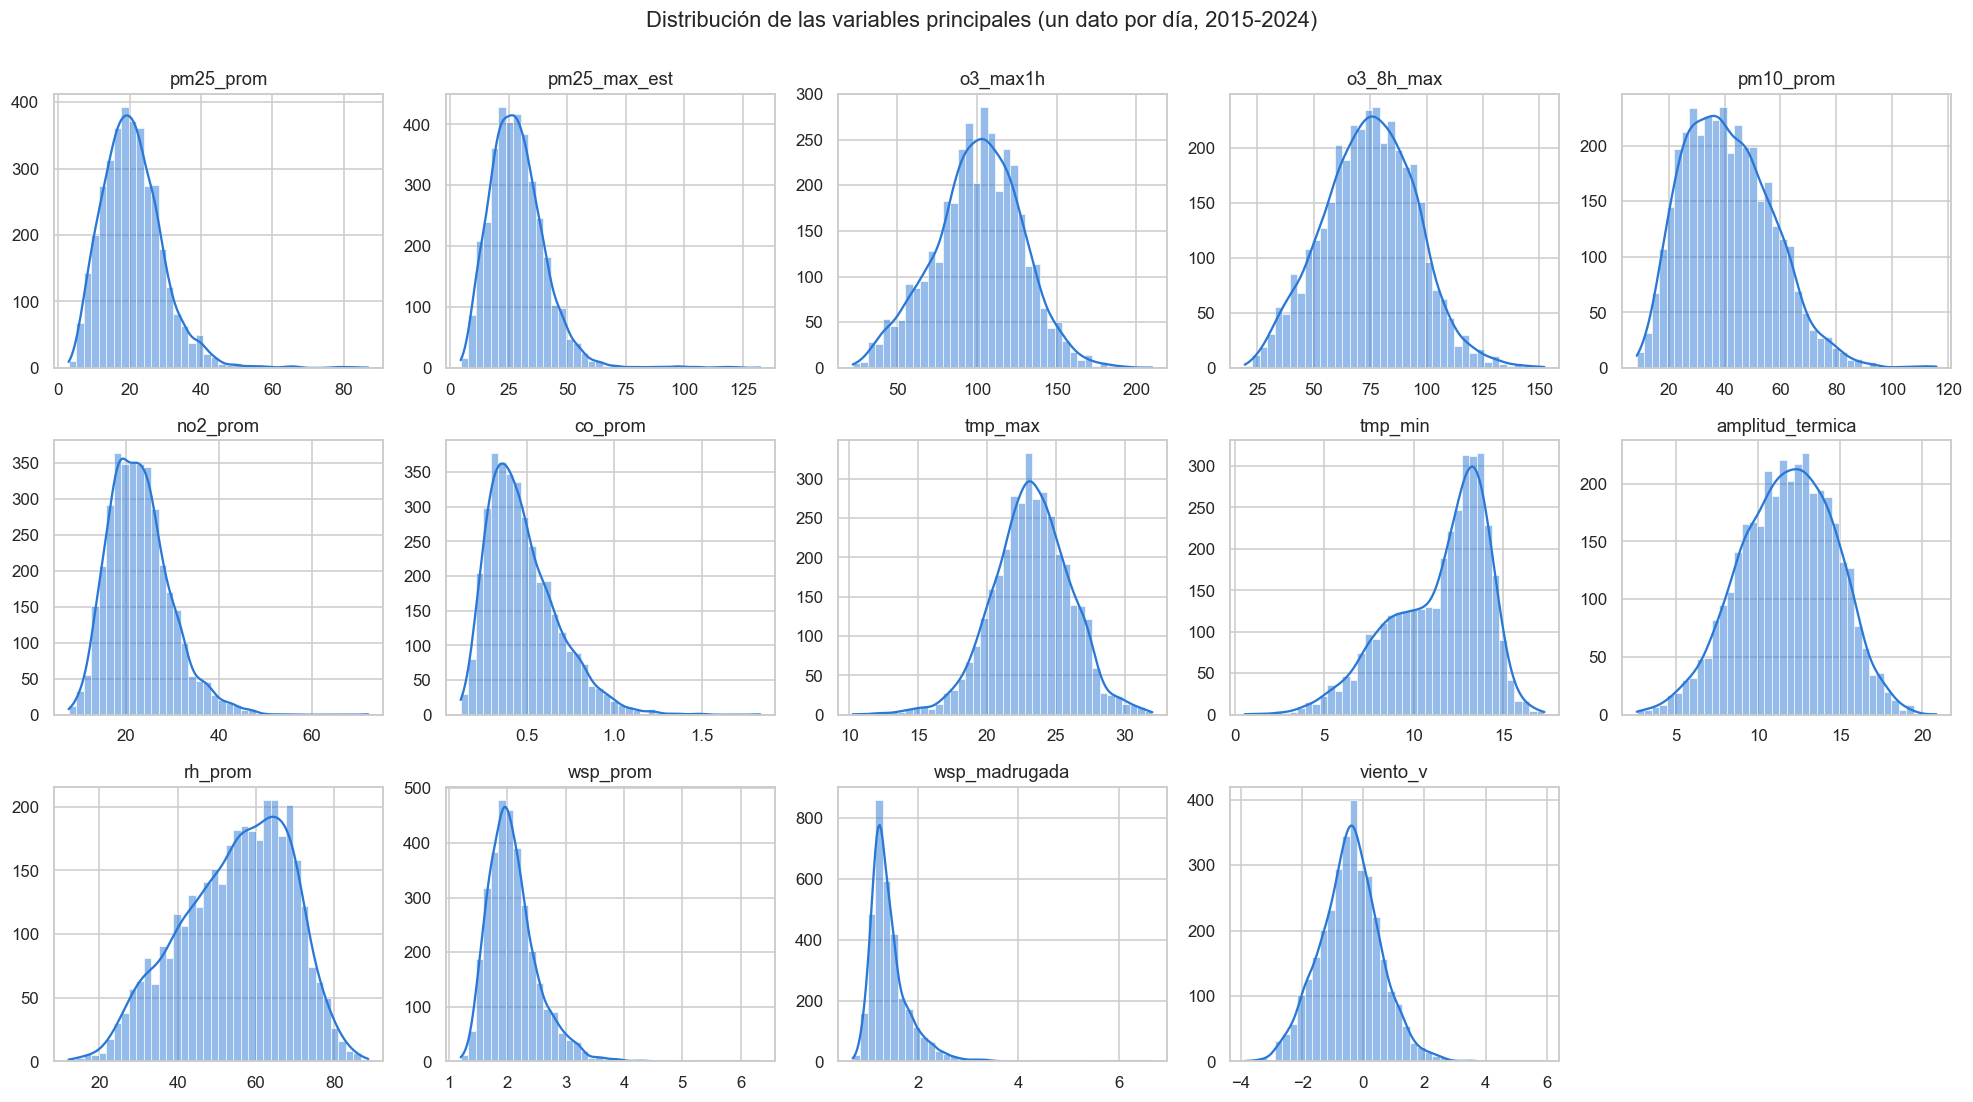

In [15]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, col in zip(axes.ravel(), PRINCIPALES):
    sns.histplot(final[col].dropna(), bins=40, ax=ax, color=COLOR["PM2.5"], kde=True)
    ax.set(title=col, xlabel="", ylabel="")
for ax in axes.ravel()[len(PRINCIPALES):]:
    ax.set_visible(False)
fig.suptitle("Distribución de las variables principales (un dato por día, 2015-2024)", y=1.0)
fig.tight_layout()
guardar(fig, "distribuciones")
plt.show()

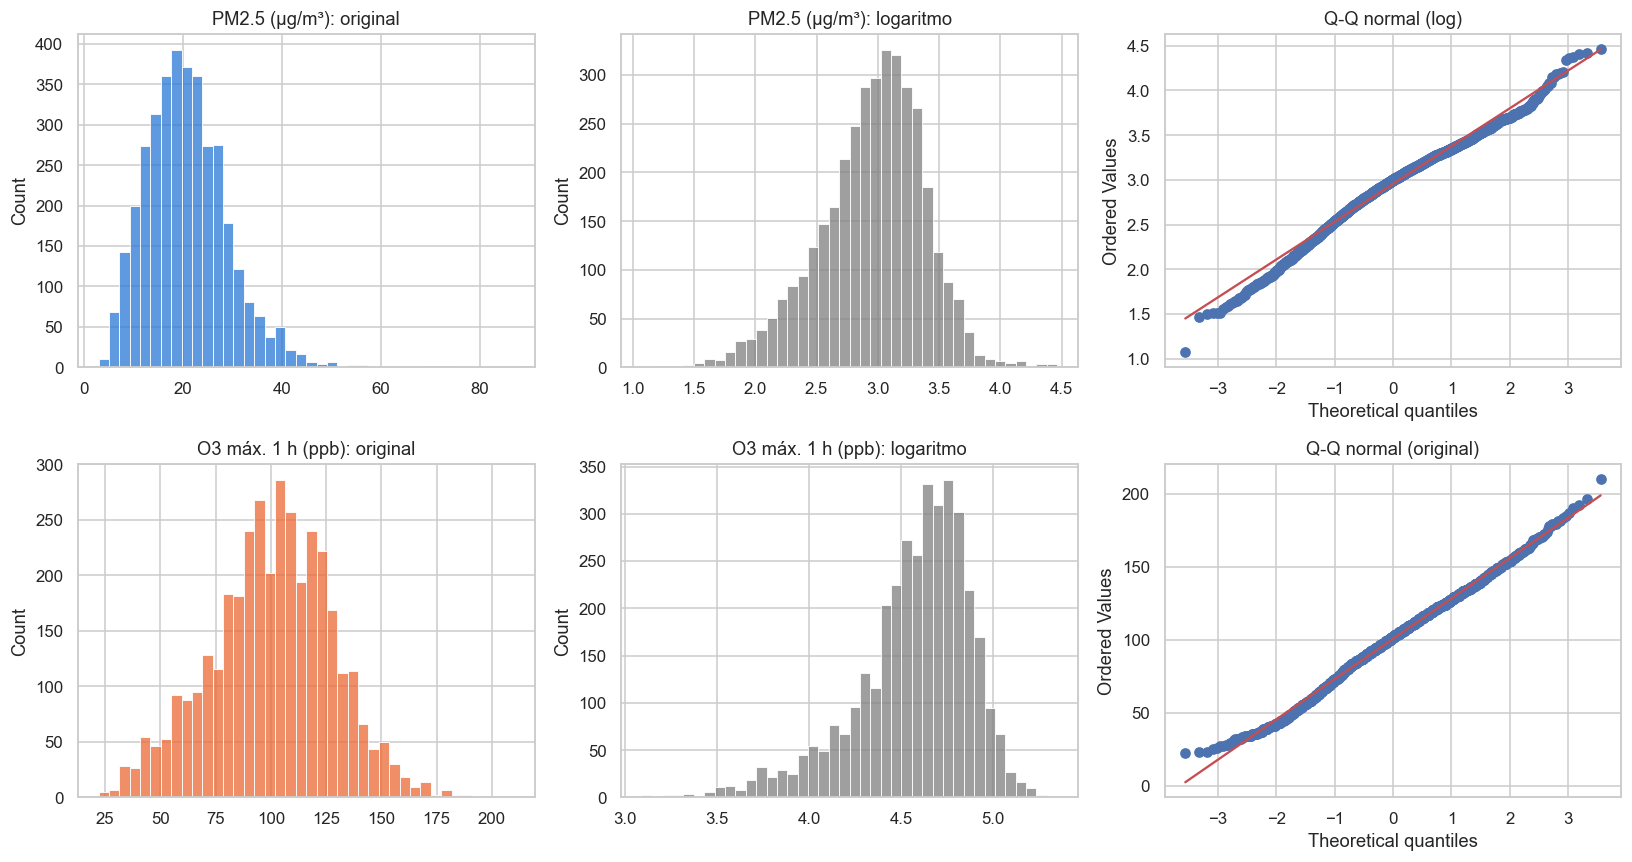

,variable,escala,asimetria,curtosis,D'Agostino K²,p
0,pm25_prom,original,1.2922,4.9449,1030.9635,0.0000
1,pm25_prom,log,-0.4292,0.4592,125.5772,0.0000
2,o3_max1h,original,-0.0965,-0.0121,5.6707,0.0587
3,o3_max1h,log,-1.0642,1.5164,600.4347,0.0000


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
normalidad = []
for fila, (col, etiqueta) in enumerate([("pm25_prom", "PM2.5 (µg/m³)"), ("o3_max1h", "O3 máx. 1 h (ppb)")]):
    x = final[col].dropna()
    lx = np.log(x)
    sns.histplot(x, bins=40, ax=axes[fila, 0], color=COLOR["PM2.5"] if fila == 0 else COLOR["O3"])
    axes[fila, 0].set(title=f"{etiqueta}: original", xlabel="")
    sns.histplot(lx, bins=40, ax=axes[fila, 1], color=COLOR["gris"])
    axes[fila, 1].set(title=f"{etiqueta}: logaritmo", xlabel="")
    stats.probplot(lx if fila == 0 else x, dist="norm", plot=axes[fila, 2])
    axes[fila, 2].set(title="Q-Q normal (" + ("log" if fila == 0 else "original") + ")")
    for nombre, serie in [("original", x), ("log", lx)]:
        k2, p = stats.normaltest(serie)
        normalidad.append({"variable": col, "escala": nombre, "asimetria": serie.skew(),
                           "curtosis": serie.kurt(), "D'Agostino K²": k2, "p": p})
fig.tight_layout()
guardar(fig, "normalidad_objetivos")
plt.show()
display(pd.DataFrame(normalidad).round(4))

- **PM2.5 no es normal** (D'Agostino, p < 0.001). Al aplicar logaritmo la asimetría baja de 1.29 a −0.43 y la gráfica Q-Q queda casi recta. Para regresión conviene **modelar log(PM2.5)**.
- **El ozono máximo horario es prácticamente normal** (p = 0.06, asimetría −0.10). No necesita transformación; el logaritmo, de hecho, lo empeora.

### 7.4 Valores atípicos

In [17]:
def atipicos_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    r = q3 - q1
    return int(((s < q1 - 1.5 * r) | (s > q3 + 1.5 * r)).sum())

tabla_at = pd.DataFrame({"atipicos_IQR": {c: atipicos_iqr(final[c].dropna()) for c in PRINCIPALES}})
tabla_at["pct"] = (tabla_at.atipicos_IQR / len(final) * 100).round(2)
display(tabla_at)

print("Los 10 días con más PM2.5")
display(final.nlargest(10, "pm25_prom").set_index("fecha")[["pm25_prom", "pm25_max_est", "wsp_prom", "rh_prom", "amplitud_termica"]]
        .round(1).assign(dia=lambda t: t.index.day_name()))
print("Los 10 días con más ozono")
display(final.nlargest(10, "o3_max1h").set_index("fecha")[["o3_max1h", "tmp_max", "rh_prom", "wsp_prom"]].round(1))

,atipicos_IQR,pct
pm25_prom,66,1.81
pm25_max_est,67,1.83
o3_max1h,25,0.68
o3_8h_max,16,0.44
pm10_prom,24,0.66
no2_prom,72,1.97
co_prom,71,1.94
tmp_max,64,1.75
tmp_min,16,0.44
amplitud_termica,10,0.27


Los 10 días con más PM2.5


,pm25_prom,pm25_max_est,wsp_prom,rh_prom,amplitud_termica,dia
fecha,,,,,,
2016-01-01,86.9,111.9,1.8,64.5,12.9,Friday
2015-12-25,82.8,123.4,1.4,58.6,13.6,Friday
2018-12-25,82.3,118.4,1.4,45.7,14.1,Tuesday
2019-05-13,79.3,97.9,2.6,28.6,12.9,Monday
2015-01-01,78.7,96.6,1.9,60.6,13.8,Thursday
2019-05-12,77.2,95.5,2.4,29.4,13.9,Sunday
2019-05-16,67.1,91.1,2.1,55.8,12.0,Thursday
2019-05-14,66.3,100.8,2.4,25.0,15.6,Tuesday
2019-05-11,65.6,86.5,2.0,29.6,14.3,Saturday


Los 10 días con más ozono


,o3_max1h,tmp_max,rh_prom,wsp_prom
fecha,,,,
2016-03-14,210.0,26.3,37.7,1.7
2016-05-04,196.0,27.1,45.5,2.3
2016-05-20,192.0,27.4,46.1,2.1
2017-05-20,190.0,29.6,40.0,2.2
2024-02-23,187.0,27.4,24.9,NaN
2017-05-23,185.0,29.7,44.5,2.2
2024-02-22,183.0,27.0,24.4,NaN
2016-03-13,181.0,26.1,35.6,1.6
2024-05-14,181.0,29.6,35.7,NaN


Los atípicos de PM2.5 (1.8% de los días) **no son errores de medición, son eventos reales**:

- **25 de diciembre y 1 de enero** (2015, 2016, 2018): pirotecnia y fogatas en noches de poco viento (1.4-1.9 m/s).
- **11 al 16 de mayo de 2019:** la contingencia ambiental extraordinaria por los incendios forestales en el centro del país, con humedad muy baja (25-30%).

Los máximos de ozono (hasta 210 ppb, el 14 de marzo de 2016, día de la primera contingencia de ozono en 14 años) se dan en primavera, con temperaturas de 26-30 °C y humedad baja.

**Decisión:** se conservan todos. Para la regresión se pueden usar modelos robustos (Huber), un indicador de festivo o ambas cosas, en lugar de borrar los eventos que justamente interesa anticipar.

### 7.5 Comportamiento en el tiempo

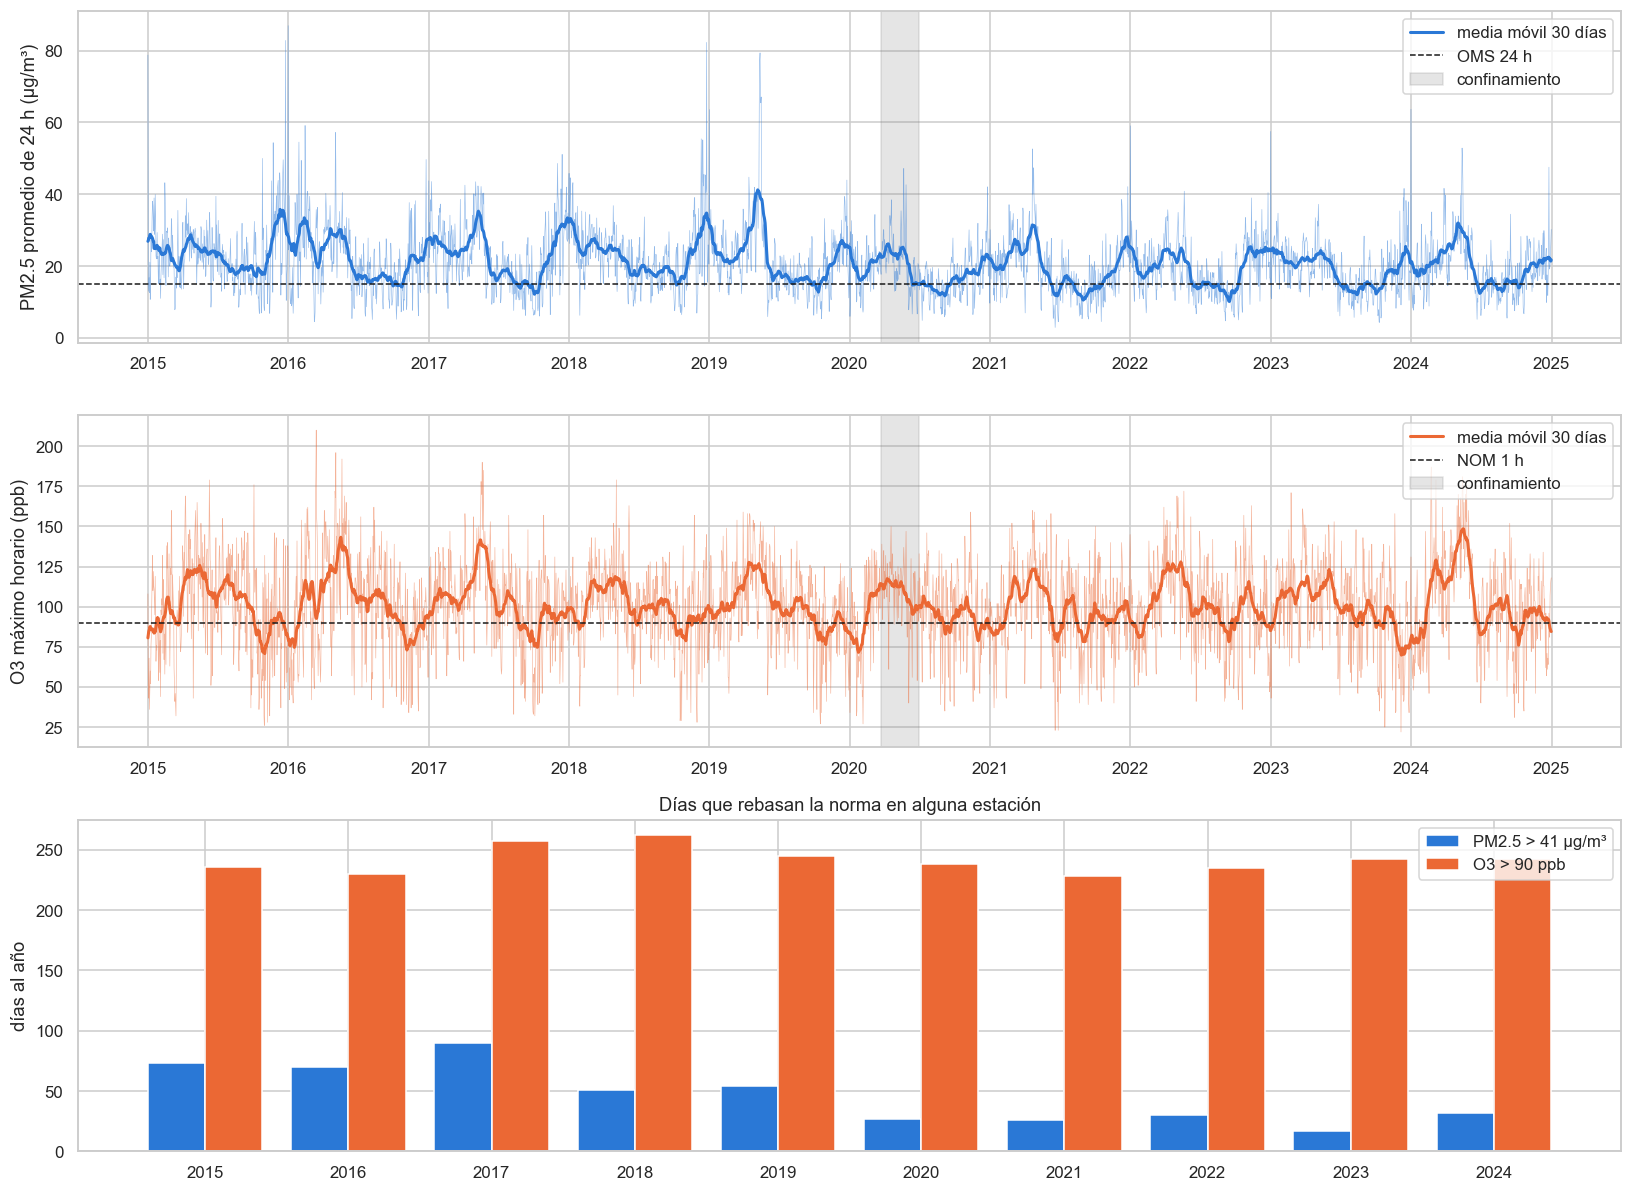

,pm25,o3,dias_pm25,dias_o3
año,,,,
2015,23.6,100.7,73.0,236.0
2016,22.0,102.2,70.0,230.0
2017,22.7,102.8,90.0,257.0
2018,22.8,99.8,51.0,262.0
2019,22.2,100.6,54.0,245.0
2020,18.6,97.8,27.0,238.0
2021,19.2,98.0,26.0,228.0
2022,19.2,100.8,30.0,235.0
2023,19.0,99.6,17.0,242.0


In [18]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=False)
for ax, (col, etiqueta, color, limite) in zip(axes[:2], [
        ("pm25_prom", "PM2.5 promedio de 24 h (µg/m³)", COLOR["PM2.5"], OMS_PM25_24H),
        ("o3_max1h", "O3 máximo horario (ppb)", COLOR["O3"], NOM_O3_1H)]):
    ax.plot(final.fecha, final[col], color=color, lw=0.4, alpha=0.5)
    ax.plot(final.fecha, final[col].rolling(30, center=True, min_periods=15).mean(), color=color, lw=2, label="media móvil 30 días")
    ax.axhline(limite, color="k", ls="--", lw=1, label="OMS 24 h" if col == "pm25_prom" else "NOM 1 h")
    ax.axvspan(pd.Timestamp("2020-03-23"), pd.Timestamp("2020-06-30"), color="grey", alpha=0.2, label="confinamiento")
    ax.set(ylabel=etiqueta)
    ax.legend(loc="upper right")

anual = final.groupby("año").agg(pm25=("pm25_prom", "mean"), o3=("o3_max1h", "mean"),
                                 dias_pm25=("excede_pm25", "sum"), dias_o3=("excede_o3", "sum"))
x = np.arange(len(anual))
axes[2].bar(x - 0.2, anual.dias_pm25, 0.4, color=COLOR["PM2.5"], label=f"PM2.5 > {NOM_PM25_24H} µg/m³")
axes[2].bar(x + 0.2, anual.dias_o3, 0.4, color=COLOR["O3"], label=f"O3 > {NOM_O3_1H} ppb")
axes[2].set_xticks(x, anual.index)
axes[2].set(ylabel="días al año", title="Días que rebasan la norma en alguna estación")
axes[2].legend()
fig.tight_layout()
guardar(fig, "serie_tiempo")
plt.show()
display(anual.round(1))

- **PM2.5 bajó de 22-24 µg/m³ (2015-2019) a 19-20 µg/m³ (2020-2024)**, y los días que rebasan la norma pasaron de 51-90 por año a 17-32. La caída empezó con la pandemia y se mantuvo.
- **El ozono no mejoró:** el promedio anual se mantiene en 98-103 ppb y entre 228 y 262 días al año rebasan la norma. Las medidas que han reducido las partículas no han tenido efecto sobre el ozono.
- La serie muestra un ciclo anual muy marcado que se repite cada año. Eso confirma que la estacionalidad (y el clima detrás de ella) es la principal fuente de variación.

### 7.6 Estacionalidad: mes, día de la semana y hora del día

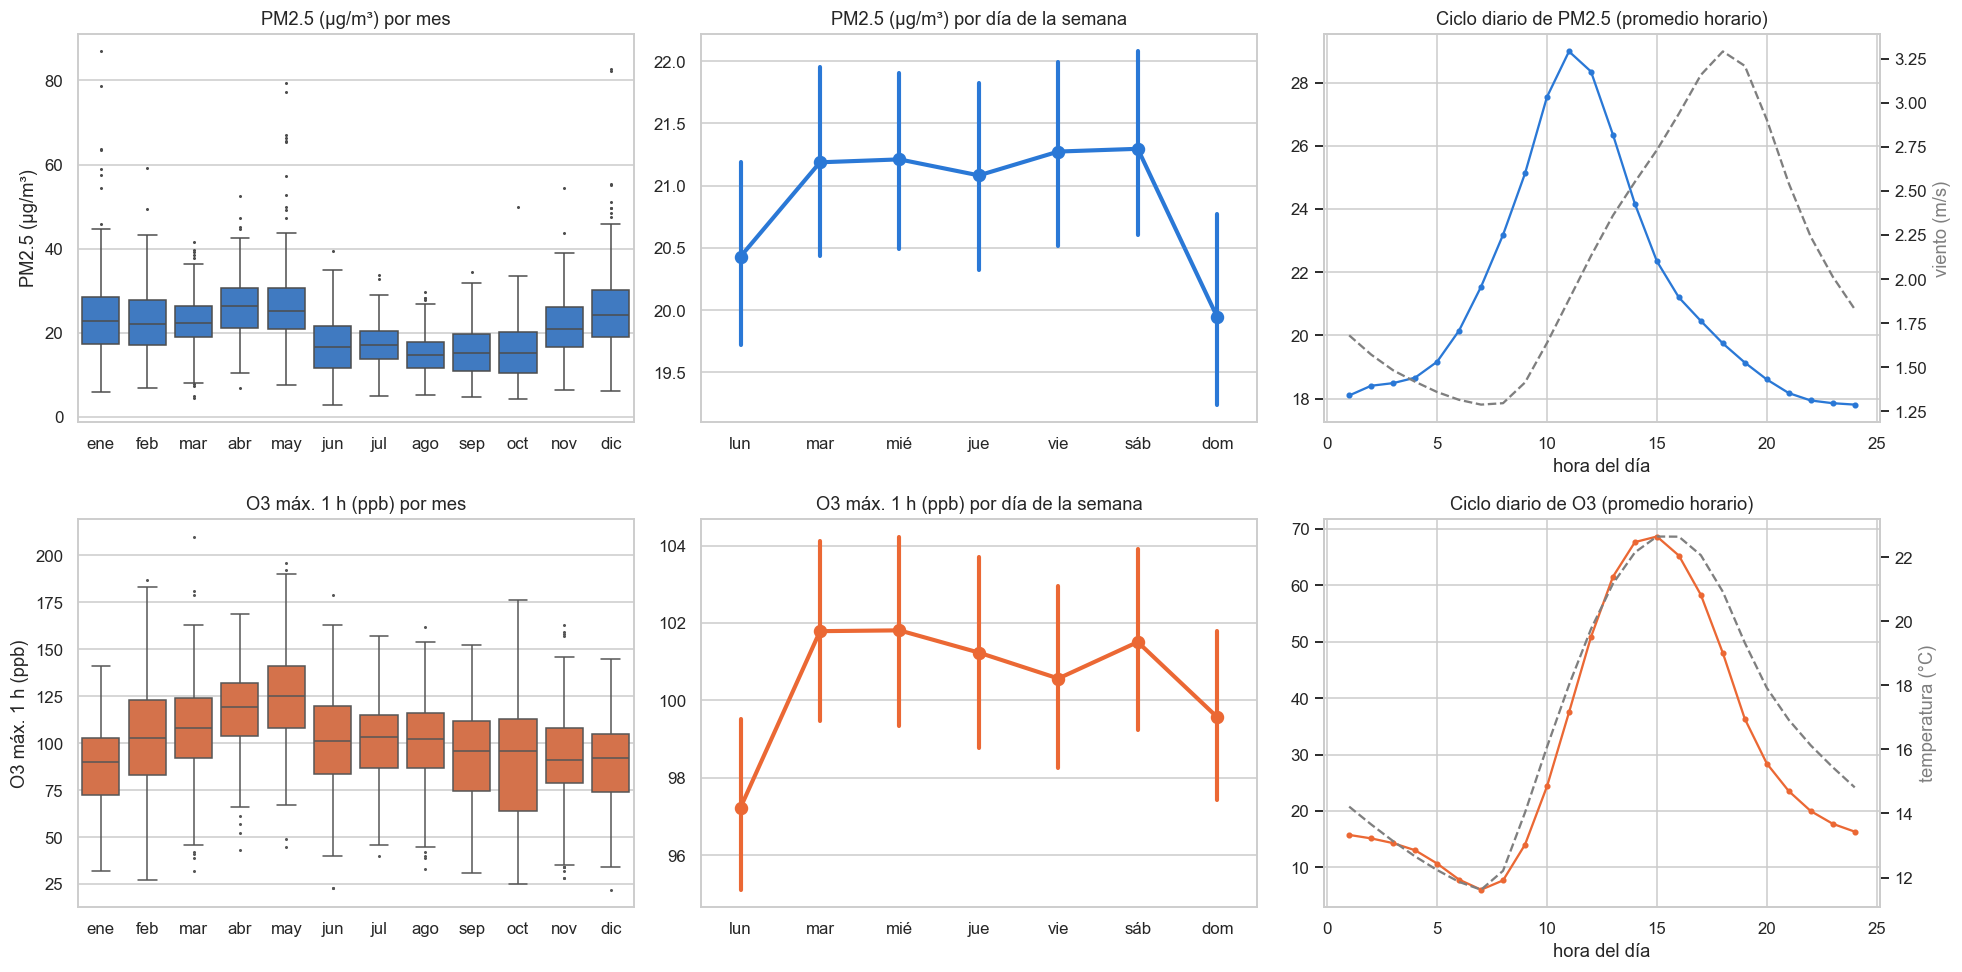

,pm25_prom,o3_max1h,% días PM2.5 > NOM,% días O3 > NOM
ene,23.9,88.0,25.8,47.4
feb,22.7,102.6,18.7,68.6
mar,22.7,107.7,10.3,77.4
abr,26.2,117.7,22.0,88.3
may,27.0,125.0,22.9,91.0
jun,17.2,100.4,3.0,65.7
jul,17.1,100.9,1.0,68.7
ago,14.9,99.6,0.3,70.3
sep,15.6,93.0,2.0,60.0
oct,16.0,90.4,2.3,55.2


In [19]:
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for fila, (col, etiqueta, color) in enumerate([("pm25_prom", "PM2.5 (µg/m³)", COLOR["PM2.5"]),
                                               ("o3_max1h", "O3 máx. 1 h (ppb)", COLOR["O3"])]):
    sns.boxplot(data=final, x="mes", y=col, ax=axes[fila, 0], color=color, fliersize=1)
    axes[fila, 0].set_xticks(range(12), MESES)
    axes[fila, 0].set(title=f"{etiqueta} por mes", xlabel="", ylabel=etiqueta)
    sns.pointplot(data=final, x="dia_semana", y=col, ax=axes[fila, 1], color=color, errorbar=("ci", 95))
    axes[fila, 1].set_xticks(range(7), DIAS)
    axes[fila, 1].set(title=f"{etiqueta} por día de la semana", xlabel="", ylabel="")
    param = "PM2.5" if fila == 0 else "O3"
    axes[fila, 2].plot(perfil_horario.index, perfil_horario[param], color=color, marker="o", ms=3)
    axes[fila, 2].set(title=f"Ciclo diario de {param} (promedio horario)", xlabel="hora del día", ylabel="")
    eje2 = axes[fila, 2].twinx()
    eje2.plot(perfil_horario.index, perfil_horario["WSP" if fila == 0 else "TMP"], color=COLOR["gris"], ls="--")
    eje2.set_ylabel("viento (m/s)" if fila == 0 else "temperatura (°C)", color=COLOR["gris"])
    eje2.grid(False)
fig.tight_layout()
guardar(fig, "estacionalidad")
plt.show()

por_mes = final.groupby("mes")[["pm25_prom", "o3_max1h", "excede_pm25", "excede_o3"]].mean()
por_mes[["excede_pm25", "excede_o3"]] *= 100
por_mes.index = MESES
display(por_mes.round(1).rename(columns={"excede_pm25": "% días PM2.5 > NOM", "excede_o3": "% días O3 > NOM"}))

- **Por mes:** el ozono sube de enero a mayo (88 → 125 ppb) y en abril y mayo **el 88-91% de los días rebasan la norma**. El PM2.5 tiene dos picos: diciembre-enero (inversiones térmicas, festividades) y abril-mayo (incendios, temporada seca). De agosto a octubre las lluvias limpian el aire (15-16 µg/m³, casi ningún día sobre la norma).
- **Por día de la semana:** las diferencias son pequeñas (alrededor de 1 µg/m³ y 4 ppb). El domingo tiene el PM2.5 más bajo y el lunes el ozono más bajo, que es cuando el aire acumulado de días anteriores es menor. En la sección 7.7 se prueba si estas diferencias son significativas.
- **Por hora:** el ozono es mínimo al amanecer (6 ppb a las 6-7 h) y llega a su máximo a las 14-15 h (69 ppb), igual que la temperatura. El PM2.5 sube desde las 6 h y llega a su máximo entre las 10 y las 12 h (29 µg/m³), después de la hora pico de tráfico y mientras el viento sigue débil (el viento es mínimo a las 6-7 h, con 1.3 m/s).

### 7.7 Comparación entre grupos

In [20]:
# Comparación entre grupos: pruebas no paramétricas porque las variables no son normales
pruebas = []
for col in ["pm25_prom", "o3_max1h"]:
    grupos = [g[col].dropna() for _, g in final.groupby("temporada")]
    h, p = stats.kruskal(*grupos)
    pruebas.append({"variable": col, "comparación": "3 temporadas (Kruskal-Wallis)", "estadístico": h, "p": p})
    sem, fds = final.loc[final.fin_semana == 0, col], final.loc[final.fin_semana == 1, col]
    u, p = stats.mannwhitneyu(sem, fds)
    pruebas.append({"variable": col, "comparación": "entre semana vs fin de semana (Mann-Whitney)", "estadístico": u, "p": p,
                    "mediana_a": sem.median(), "mediana_b": fds.median()})
display(pd.DataFrame(pruebas).round(4))
display(final.groupby("temporada")[["pm25_prom", "o3_max1h", "tmp_max", "rh_prom", "wsp_prom", "amplitud_termica"]]
        .median().round(1))

# Efecto del confinamiento: mismo periodo del año (23 mar - 30 jun) en 2020 vs promedio 2017-2019
periodo = final[(final.fecha.dt.strftime("%m-%d") >= "03-23") & (final.fecha.dt.strftime("%m-%d") <= "06-30")]
conf = periodo.assign(grupo=np.where(periodo.año == 2020, "2020", np.where(periodo.año.between(2017, 2019), "2017-2019", None)))
conf = conf.dropna(subset=["grupo"]).groupby("grupo")[["pm25_prom", "no2_prom", "co_prom", "o3_max1h"]].mean()
conf.loc["cambio_%"] = (conf.loc["2020"] / conf.loc["2017-2019"] - 1) * 100
print("23 de marzo a 30 de junio: 2020 (confinamiento) vs. promedio 2017-2019")
display(conf.round(1))

,variable,comparación,estadístico,p,mediana_a,mediana_b
0,pm25_prom,3 temporadas (Kruskal-Wallis),9.423490e+02,0.0000,NaN,NaN
1,pm25_prom,entre semana vs fin de semana (Mann-Whitney),1.400314e+06,0.1822,20.2132,19.6533
2,o3_max1h,3 temporadas (Kruskal-Wallis),4.388289e+02,0.0000,NaN,NaN
3,o3_max1h,entre semana vs fin de semana (Mann-Whitney),1.347246e+06,0.6109,101.0000,103.0000


,pm25_prom,o3_max1h,tmp_max,rh_prom,wsp_prom,amplitud_termica
temporada,,,,,,
Lluvias,15.8,100.0,23.2,65.3,2.0,10.0
Seca caliente,24.1,118.0,25.8,43.6,2.2,13.2
Seca fría,22.7,93.0,21.8,51.2,1.9,13.3


23 de marzo a 30 de junio: 2020 (confinamiento) vs. promedio 2017-2019


,pm25_prom,no2_prom,co_prom,o3_max1h
grupo,,,,
2017-2019,25.2,22.2,0.4,114.4
2020,21.8,15.5,0.3,109.3
cambio_%,-13.5,-30.4,-39.7,-4.5


Usamos pruebas no paramétricas (Kruskal-Wallis y Mann-Whitney) porque PM2.5 no es normal.

- **Temporada:** las diferencias son muy significativas para los dos contaminantes (p < 0.001). La seca caliente tiene la mediana más alta de ozono (118 ppb) y de PM2.5 (24.1). La de lluvias, la más baja de PM2.5 (15.8).
- **Fin de semana:** **no hay diferencia significativa** ni en PM2.5 (p = 0.18) ni en ozono (p = 0.61). Esto sugiere que la variación diaria depende más del clima que del volumen de tráfico de un día específico.
- **Confinamiento 2020:** entre el 23 de marzo y el 30 de junio de 2020, frente al mismo periodo de 2017-2019, el CO bajó 40%, el NO2 30% y el PM2.5 13.5%, pero **el ozono solo bajó 4.5%**. Es un experimento natural: reducir mucho el tráfico no bajó el ozono en la misma proporción, porque su formación depende de la química y del clima, no solo de cuánto se emite.

### 7.8 Correlaciones y multicolinealidad

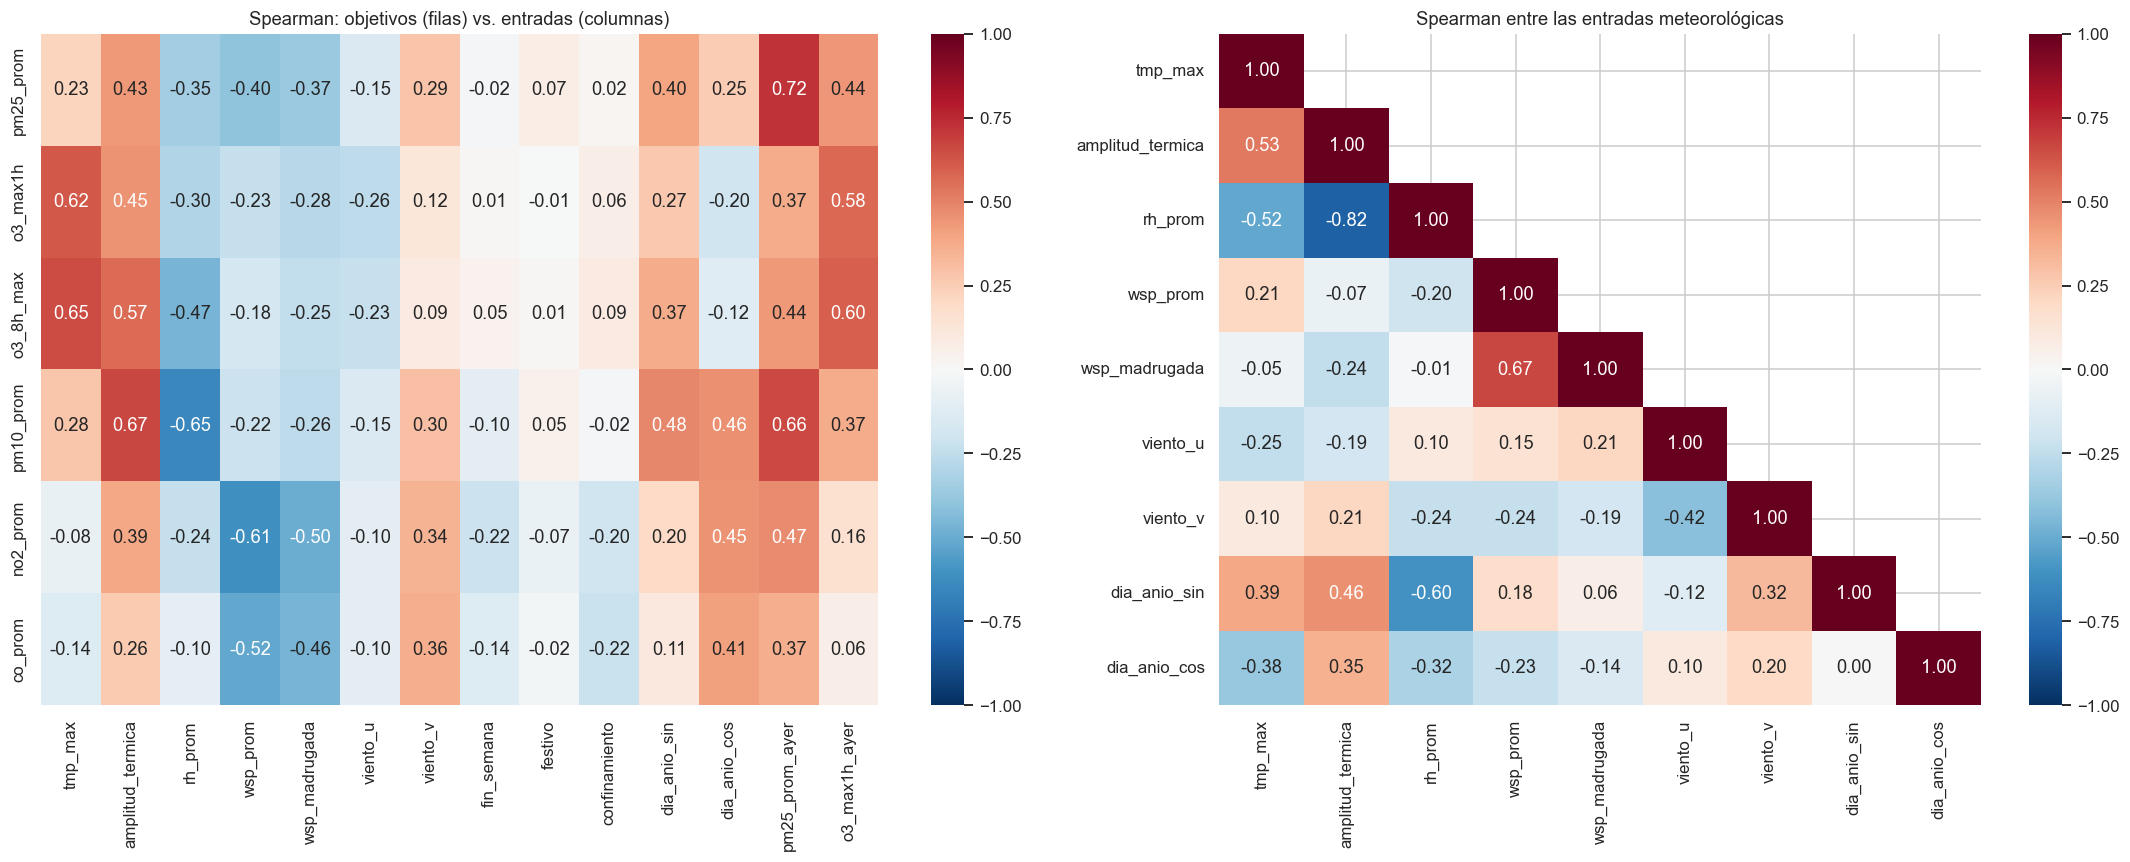

Correlación (Spearman) de cada entrada con los dos objetivos principales, ordenada


,pm25_prom,o3_max1h
pm25_prom_ayer,0.72,0.37
o3_max1h_ayer,0.44,0.58
amplitud_termica,0.43,0.45
wsp_prom,-0.40,-0.23
dia_anio_sin,0.40,0.27
wsp_madrugada,-0.37,-0.28
rh_prom,-0.35,-0.30
viento_v,0.29,0.12
dia_anio_cos,0.25,-0.20
tmp_max,0.23,0.62


In [21]:
ENTRADAS = ["tmp_max", "amplitud_termica", "rh_prom", "wsp_prom", "wsp_madrugada", "viento_u", "viento_v",
            "fin_semana", "festivo", "confinamiento", "dia_anio_sin", "dia_anio_cos", "pm25_prom_ayer", "o3_max1h_ayer"]
OBJETIVOS = ["pm25_prom", "o3_max1h", "o3_8h_max", "pm10_prom", "no2_prom", "co_prom"]

corr = final[OBJETIVOS + ENTRADAS].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={"width_ratios": [1.1, 1]})
sns.heatmap(corr.loc[OBJETIVOS, ENTRADAS], annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Spearman: objetivos (filas) vs. entradas (columnas)")
met = ["tmp_max", "amplitud_termica", "rh_prom", "wsp_prom", "wsp_madrugada", "viento_u", "viento_v",
       "dia_anio_sin", "dia_anio_cos"]
sns.heatmap(corr.loc[met, met], annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1], mask=np.triu(np.ones((len(met),) * 2), 1).astype(bool))
axes[1].set_title("Spearman entre las entradas meteorológicas")
fig.tight_layout()
guardar(fig, "correlaciones")
plt.show()

print("Correlación (Spearman) de cada entrada con los dos objetivos principales, ordenada")
display(corr.loc[ENTRADAS, ["pm25_prom", "o3_max1h"]].sort_values("pm25_prom", key=abs, ascending=False).round(2))

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(final[ENTRADAS].dropna())
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
                index=ENTRADAS, name="VIF").sort_values(ascending=False)
display(vif.round(2).to_frame())

,VIF
rh_prom,4.83
amplitud_termica,4.78
tmp_max,4.26
dia_anio_cos,3.16
wsp_prom,2.58
wsp_madrugada,2.50
o3_max1h_ayer,2.12
pm25_prom_ayer,1.94
dia_anio_sin,1.94
viento_v,1.51


Usamos Spearman porque varias variables son asimétricas.

- **PM2.5** se relaciona sobre todo con el **valor del día anterior** (ρ = 0.72), la **amplitud térmica** (0.43, cielos despejados con inversión), la estacionalidad y, en sentido negativo, con el **viento** (−0.40 el promedio del día, −0.37 el de la madrugada) y la **humedad** (−0.35).
- **El ozono** se relaciona sobre todo con la **temperatura máxima** (ρ = 0.62), su valor del día anterior (0.58) y la amplitud térmica (0.45), y negativamente con la humedad (−0.30).
- **El fin de semana, los festivos y el confinamiento tienen correlación casi nula** con los valores diarios.
- **Multicolinealidad:** `tmp_min` se excluye de las entradas porque es exactamente `tmp_max − amplitud_termica` (con ella el VIF se vuelve infinito). Sin ella, todos los VIF quedan por debajo de 5; los más altos son la humedad (4.8), la amplitud térmica (4.8) y la temperatura máxima (4.3). No hay multicolinealidad grave.

### 7.9 Relación entre meteorología y contaminación

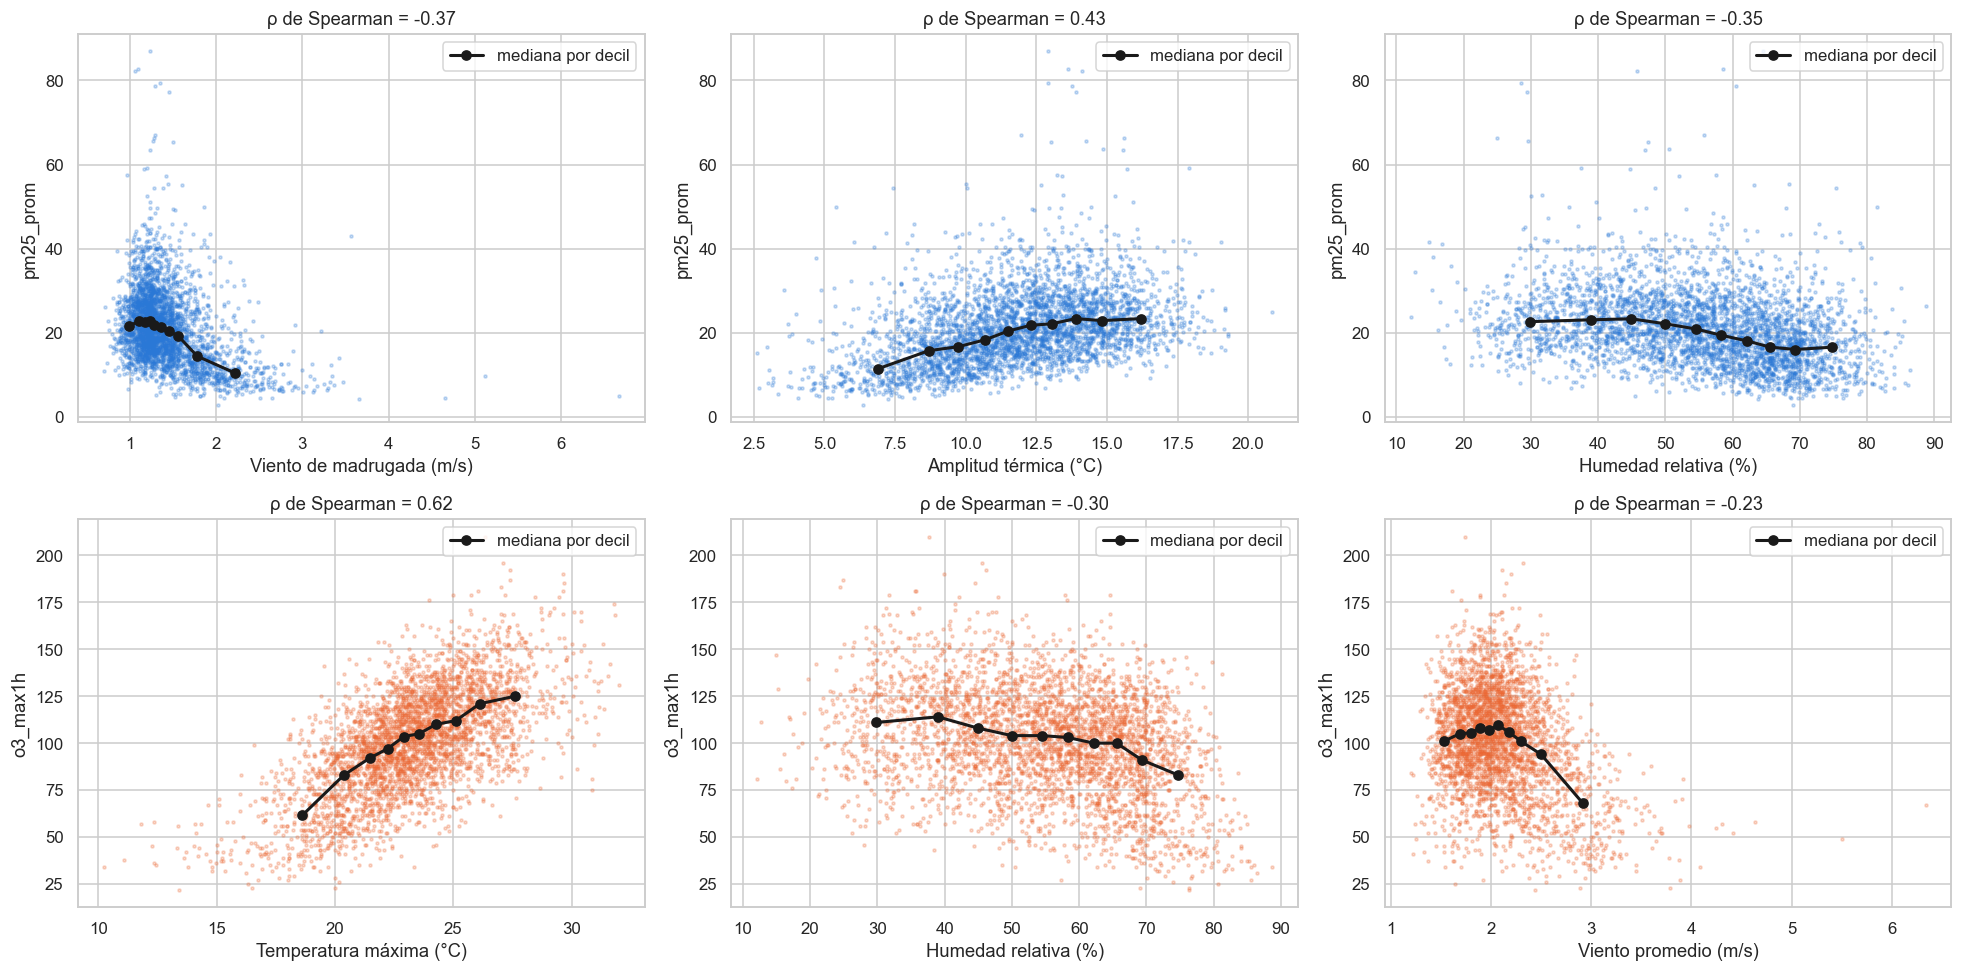

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
pares = [("wsp_madrugada", "pm25_prom", "Viento de madrugada (m/s)"),
         ("amplitud_termica", "pm25_prom", "Amplitud térmica (°C)"),
         ("rh_prom", "pm25_prom", "Humedad relativa (%)"),
         ("tmp_max", "o3_max1h", "Temperatura máxima (°C)"),
         ("rh_prom", "o3_max1h", "Humedad relativa (%)"),
         ("wsp_prom", "o3_max1h", "Viento promedio (m/s)")]
for ax, (x, y, etiqueta) in zip(axes.ravel(), pares):
    color = COLOR["PM2.5"] if y == "pm25_prom" else COLOR["O3"]
    d = final[[x, y]].dropna()
    ax.scatter(d[x], d[y], s=4, alpha=0.25, color=color)
    # tendencia: mediana por decil de x
    bins = pd.qcut(d[x], 10, duplicates="drop")
    tend = d.groupby(bins, observed=True).agg(xm=(x, "median"), ym=(y, "median"))
    ax.plot(tend.xm, tend.ym, color="k", marker="o", lw=2, label="mediana por decil")
    rho = stats.spearmanr(d[x], d[y])[0]
    ax.set(xlabel=etiqueta, ylabel=y, title=f"ρ de Spearman = {rho:.2f}")
    ax.legend(loc="upper right")
fig.tight_layout()
guardar(fig, "meteorologia_vs_contaminacion")
plt.show()

Las medianas por decil muestran relaciones claras y en buena parte **no lineales**:

- **Viento de madrugada:** el PM2.5 se mantiene alto (≈22 µg/m³) mientras el viento es menor a ~1.5 m/s y cae a la mitad (≈10 µg/m³) cuando pasa de 2 m/s. Es un efecto de umbral, no una línea recta.
- **Amplitud térmica:** el PM2.5 sube de ≈11 a ≈23 µg/m³ entre 7 y 13 °C de amplitud y después se estabiliza.
- **Humedad:** el PM2.5 casi no cambia hasta 45% y baja después.
- **Temperatura:** el ozono sube casi en línea recta con la temperatura máxima, de ≈60 ppb a 19 °C a ≈125 ppb a 28 °C. Es la relación más fuerte del análisis.
- **Humedad y viento:** el ozono se mantiene alto con humedad menor a 65% y viento menor a 2 m/s, y cae rápido por arriba de esos valores.

Esto justifica probar **regresión polinomial y redes neuronales** en la siguiente etapa, no solo regresión lineal.

### 7.10 Autocorrelación

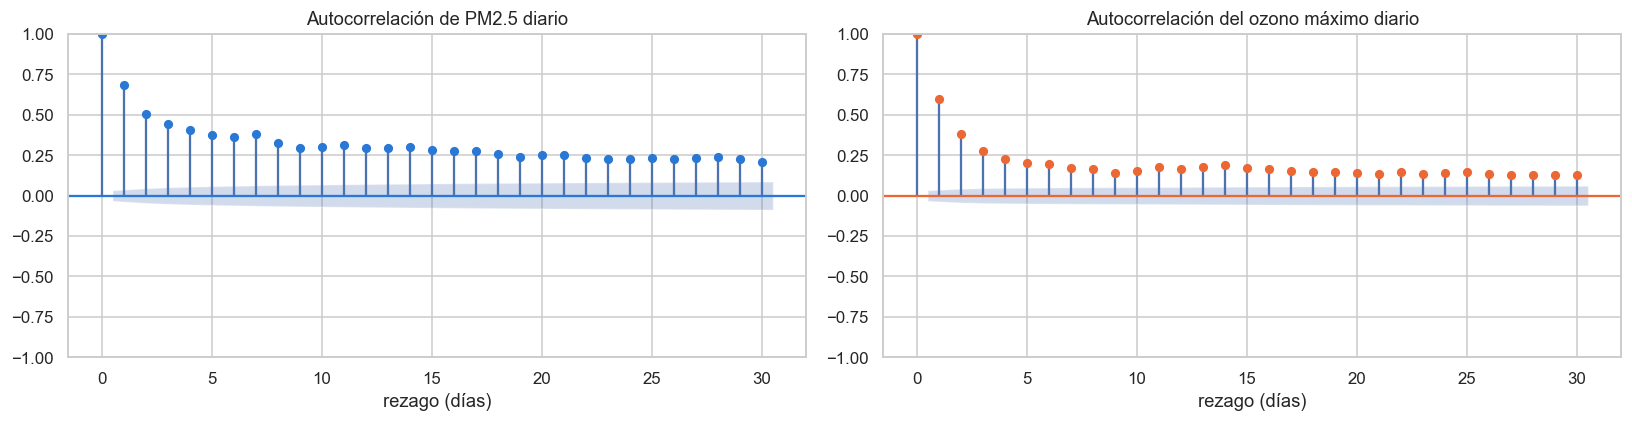

pm25_prom | autocorrelación a 1 día: 0.69 | a 7 días: 0.38
o3_max1h | autocorrelación a 1 día: 0.59 | a 7 días: 0.17


In [24]:
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(final.pm25_prom.dropna(), lags=30, ax=axes[0], color=COLOR["PM2.5"])
axes[0].set(title="Autocorrelación de PM2.5 diario", xlabel="rezago (días)")
plot_acf(final.o3_max1h.dropna(), lags=30, ax=axes[1], color=COLOR["O3"])
axes[1].set(title="Autocorrelación del ozono máximo diario", xlabel="rezago (días)")
fig.tight_layout()
guardar(fig, "autocorrelacion")
plt.show()
for col in ["pm25_prom", "o3_max1h"]:
    print(col, "| autocorrelación a 1 día:", round(final[col].autocorr(1), 2), "| a 7 días:", round(final[col].autocorr(7), 2))

Las dos series tienen **autocorrelación alta a 1 día** (PM2.5 0.69, ozono 0.59), que baja lentamente. Los episodios duran varios días. Hay dos consecuencias:

1. El valor del día anterior es un buen predictor.
2. Para evaluar modelos **no se pueden mezclar días al azar** entre entrenamiento y prueba, porque días vecinos casi iguales quedarían en los dos lados. La partición tiene que ser por tiempo.

### 7.11 Primera aproximación con regresión lineal

Para medir qué tan útiles son las variables, ajustamos regresiones lineales con **partición por tiempo**: entrenamos con 2015-2021 y probamos con 2022-2023. No se usa 2024 porque no tiene viento. PM2.5 se modela en logaritmo y las métricas se calculan en µg/m³.

,objetivo,modelo,variables,R² entrenamiento,R² prueba,MAE prueba,RMSE prueba
0,pm25_prom,Solo meteorología,7,0.287,0.222,4.939,6.253
1,pm25_prom,Meteorología + calendario,12,0.362,0.296,4.661,5.948
2,pm25_prom,Meteorología + calendario + día anterior,13,0.553,0.544,3.442,4.787
3,pm25_prom,Solo el día anterior (persistencia),1,0.166,0.306,4.128,5.903
0,o3_max1h,Solo meteorología,7,0.570,0.591,14.055,17.126
1,o3_max1h,Meteorología + calendario,12,0.596,0.589,14.093,17.177
2,o3_max1h,Meteorología + calendario + día anterior,13,0.656,0.656,12.639,15.707
3,o3_max1h,Solo el día anterior (persistencia),1,0.336,0.356,16.823,21.501


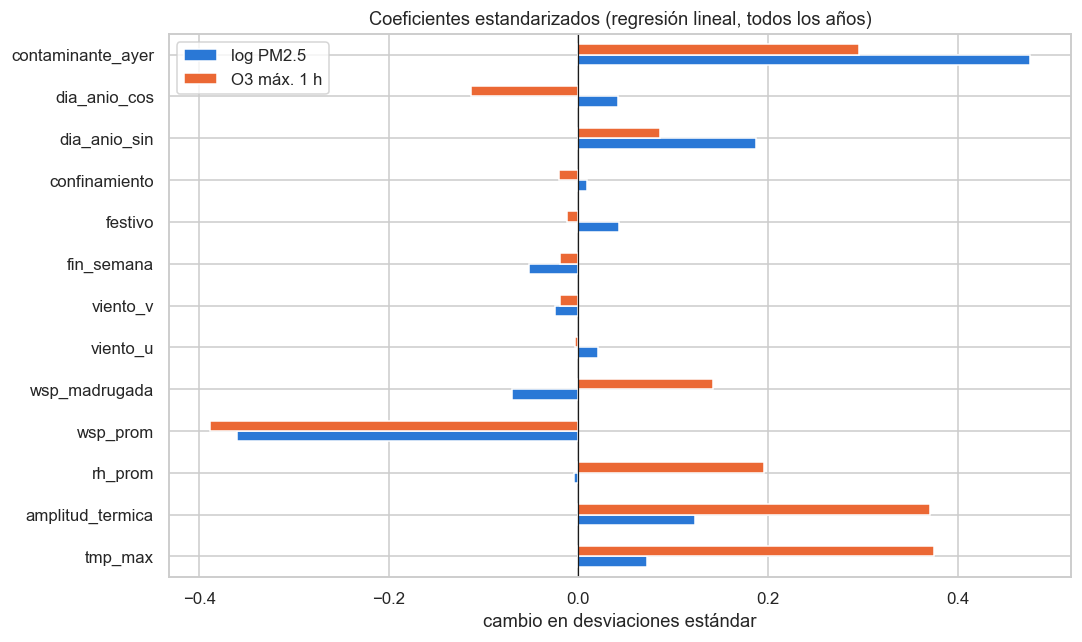

,log PM2.5,O3 máx. 1 h
tmp_max,0.073,0.375
amplitud_termica,0.122,0.371
rh_prom,-0.004,0.195
wsp_prom,-0.360,-0.389
wsp_madrugada,-0.070,0.142
viento_u,0.021,-0.003
viento_v,-0.025,-0.020
fin_semana,-0.052,-0.019
festivo,0.042,-0.012
confinamiento,0.009,-0.021


In [25]:
# Primera aproximación: regresión lineal con partición temporal (entrenar 2015-2021, probar 2022-2023; 2024 no tiene viento)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

METEO = ["tmp_max", "amplitud_termica", "rh_prom", "wsp_prom", "wsp_madrugada", "viento_u", "viento_v"]
CALEND = ["fin_semana", "festivo", "confinamiento", "dia_anio_sin", "dia_anio_cos"]

def evaluar(objetivo, rezago, log=False):
    datos = final.dropna(subset=[objetivo] + METEO + CALEND + [rezago])
    entrena, prueba = datos[datos.año <= 2021], datos[datos.año.between(2022, 2023)]
    filas = []
    for nombre, cols in [("Solo meteorología", METEO), ("Meteorología + calendario", METEO + CALEND),
                         ("Meteorología + calendario + día anterior", METEO + CALEND + [rezago]),
                         ("Solo el día anterior (persistencia)", [rezago])]:
        X_tr, X_te = entrena[cols], prueba[cols]
        y_tr = np.log(entrena[objetivo]) if log else entrena[objetivo]
        m = LinearRegression().fit(X_tr, y_tr)
        pred = m.predict(X_te)
        pred = np.exp(pred) if log else pred
        filas.append({"objetivo": objetivo, "modelo": nombre, "variables": len(cols),
                      "R² entrenamiento": r2_score(entrena[objetivo], np.exp(m.predict(X_tr)) if log else m.predict(X_tr)),
                      "R² prueba": r2_score(prueba[objetivo], pred),
                      "MAE prueba": mean_absolute_error(prueba[objetivo], pred),
                      "RMSE prueba": mean_squared_error(prueba[objetivo], pred) ** 0.5})
    return pd.DataFrame(filas)

resultados = pd.concat([evaluar("pm25_prom", "pm25_prom_ayer", log=True), evaluar("o3_max1h", "o3_max1h_ayer")])
display(resultados.round(3))

# Coeficientes estandarizados del modelo completo (qué variables pesan más)
def coef_std(objetivo, rezago, log=False):
    datos = final.dropna(subset=[objetivo] + METEO + CALEND + [rezago])
    cols = METEO + CALEND + [rezago]
    X = (datos[cols] - datos[cols].mean()) / datos[cols].std()
    y = np.log(datos[objetivo]) if log else datos[objetivo]
    y = (y - y.mean()) / y.std()
    return pd.Series(LinearRegression().fit(X, y).coef_, index=cols)

coefs = pd.DataFrame({"log PM2.5": coef_std("pm25_prom", "pm25_prom_ayer", True),
                      "O3 máx. 1 h": coef_std("o3_max1h", "o3_max1h_ayer")}).rename(index={"pm25_prom_ayer": "contaminante_ayer", "o3_max1h_ayer": "contaminante_ayer"})
coefs = coefs.groupby(level=0).sum().reindex(METEO + CALEND + ["contaminante_ayer"])
fig, ax = plt.subplots(figsize=(10, 6))
coefs.plot.barh(ax=ax, color=[COLOR["PM2.5"], COLOR["O3"]])
ax.axvline(0, color="k", lw=0.8)
ax.set(title="Coeficientes estandarizados (regresión lineal, todos los años)", xlabel="cambio en desviaciones estándar")
fig.tight_layout()
guardar(fig, "coeficientes")
plt.show()
display(coefs.round(3))

- **Ozono:** **solo con la meteorología del día se explica el 59% de la variación** en los años de prueba (MAE ≈ 14 ppb). Al agregar el valor del día anterior sube a **66%** (MAE ≈ 12.6 ppb). En los coeficientes estandarizados, las variables que más pesan son el viento (−0.39), la temperatura máxima (+0.38) y la amplitud térmica (+0.37), por encima del ozono del día anterior (+0.30).
- **PM2.5:** la meteorología sola explica el 22%, con calendario 30% y **con el día anterior 54%** (MAE ≈ 3.4 µg/m³). El PM2.5 depende más de la persistencia (coeficiente +0.48), del viento (−0.36) y de eventos puntuales (incendios, pirotecnia), así que es más difícil de predecir.
- **Los modelos completos superan a la persistencia** (usar solo el valor de ayer: 31% en PM2.5 y 36% en ozono). La meteorología aporta información que no está en el día anterior.
- El R² de prueba es parecido al de entrenamiento, así que el modelo lineal **no está sobreajustado**. Queda espacio para mejorar con modelos no lineales.
- En el modelo con todas las variables, la humedad aparece con signo positivo para el ozono aunque su correlación simple es negativa. Esto pasa porque la humedad está relacionada con la temperatura y la amplitud térmica: hay que leer los coeficientes juntos, no uno por uno.

## Parte B — Análisis espacial: quién respira la contaminación

### 7.12 Validación del satélite con las estaciones (2020)

En el EDA anterior usamos el satélite para todas las localidades, pero no sabíamos si era confiable. Ahora lo comparamos con lo que midió cada estación de la RAMA en 2020.

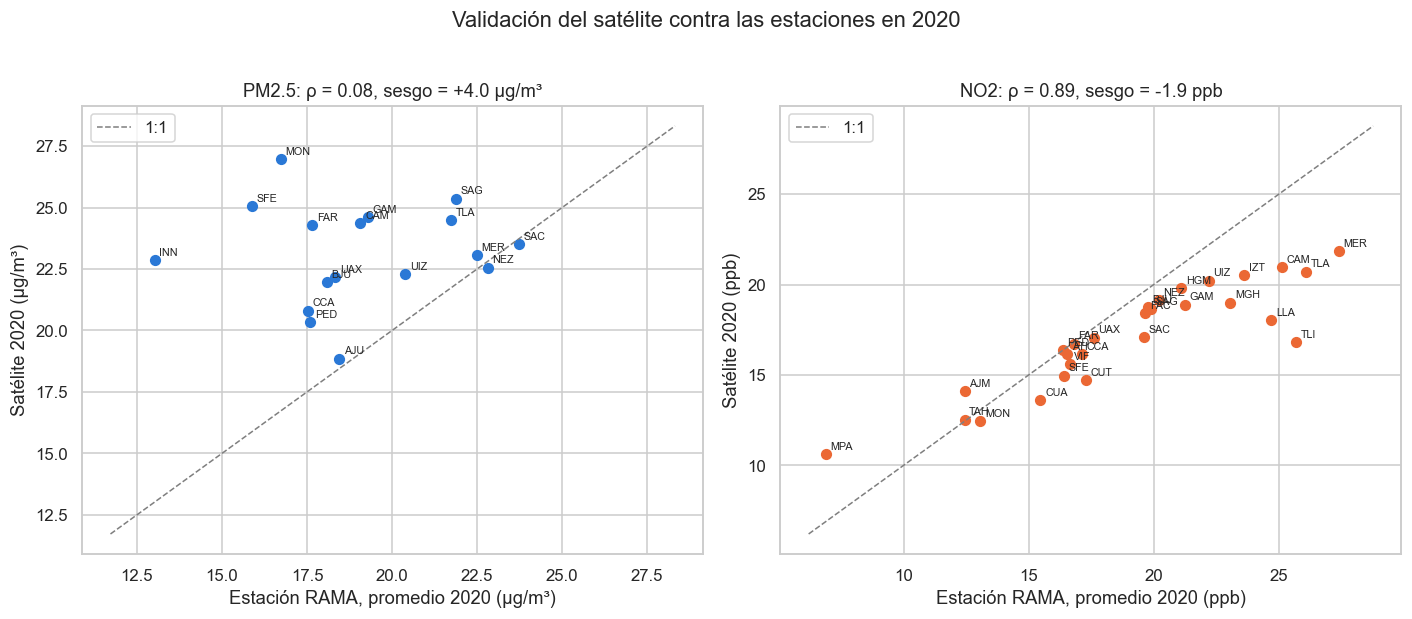

,contaminante,estaciones,Spearman ρ,p,Pearson r,sesgo medio (satélite − estación),promedio estaciones,promedio satélite
0,PM2.5,17,0.081,0.758,0.062,4.048,19.100,23.149
1,NO2,28,0.894,0.000,0.899,-1.946,19.084,17.139


In [26]:
# ¿El satélite (EDA anterior) reproduce lo que midieron las estaciones (datos nuevos) en 2020?
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
validacion = []
for ax, (medido, sat, etiqueta, unidad) in zip(axes, [("pm25_prom_2020", "pm25_sat", "PM2.5", "µg/m³"),
                                                    ("no2_prom_2020", "no2_sat", "NO2", "ppb")]):
    d = est[[medido, sat, "id_station"]].dropna()
    rho, p = stats.spearmanr(d[medido], d[sat])
    r = np.corrcoef(d[medido], d[sat])[0, 1]
    sesgo = (d[sat] - d[medido]).mean()
    validacion.append({"contaminante": etiqueta, "estaciones": len(d), "Spearman ρ": rho, "p": p, "Pearson r": r,
                       f"sesgo medio (satélite − estación)": sesgo, "promedio estaciones": d[medido].mean(),
                       "promedio satélite": d[sat].mean()})
    ax.scatter(d[medido], d[sat], color=COLOR["PM2.5"] if etiqueta == "PM2.5" else COLOR["O3"], s=40)
    for _, f in d.iterrows():
        ax.annotate(f.id_station, (f[medido], f[sat]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    lim = [min(d[medido].min(), d[sat].min()) * 0.9, max(d[medido].max(), d[sat].max()) * 1.05]
    ax.plot(lim, lim, color=COLOR["gris"], ls="--", lw=1, label="1:1")
    ax.set(xlabel=f"Estación RAMA, promedio 2020 ({unidad})", ylabel=f"Satélite 2020 ({unidad})",
           title=f"{etiqueta}: ρ = {rho:.2f}, sesgo = {sesgo:+.1f} {unidad}")
    ax.legend()
fig.suptitle("Validación del satélite contra las estaciones en 2020", y=1.02)
fig.tight_layout()
guardar(fig, "validacion_satelite")
plt.show()
display(pd.DataFrame(validacion).round(3))

- **NO2: el satélite es confiable.** Reproduce muy bien el orden de las estaciones (ρ = 0.89, r = 0.90, 28 estaciones) y subestima apenas 1.9 ppb en promedio. Se puede usar para las localidades que no tienen estación.
- **PM2.5: el satélite NO reproduce las diferencias entre estaciones** (ρ = 0.08, p = 0.76, 17 estaciones) y sobreestima 4 µg/m³ en promedio (23.1 contra 19.1). Sirve para el nivel general y para comparar con la norma anual, pero no para decir qué zona de la ciudad tiene más PM2.5.
- Esto cambia una conclusión del EDA anterior: los contrastes de PM2.5 satelital entre localidades no son confiables; los de NO2 sí.

### 7.13 Exposición de la población y población vulnerable

In [27]:
def media_pond(x, w):
    ok = x.notna() & w.notna()
    return np.average(x[ok], weights=w[ok]) if ok.any() else np.nan

def resumen_exposicion(g):
    """Exposición de la población (función del EDA anterior, ampliada con los días sobre la norma de la RAMA)."""
    w = g.POBTOT
    cerca = g.o3_dias_sobre_nom.notna()
    return pd.Series({
        "localidades": len(g),
        "población": w.sum(),
        "PM2.5 satélite ponderado (µg/m³)": media_pond(g.pm25_sat, w),
        "NO2 satélite ponderado (ppb)": media_pond(g.no2_sat, w),
        "% pob. sobre NOM anual PM2.5 (10)": w[g.pm25_sat > 10].sum() / w.sum() * 100,
        "% pob. sobre OMS anual PM2.5 (5)": w[g.pm25_sat > 5].sum() / w.sum() * 100,
        f"% pob. a ≤{RADIO_KM} km de estación O3": w[cerca].sum() / w.sum() * 100,
        "días/año O3 > 90 ppb (pob. cubierta)": media_pond(g.o3_dias_sobre_nom, w),
    })

expo = loc.groupby("NOM_ENT").apply(resumen_exposicion)
display(expo.round(1))

# Población vulnerable que vive cerca de una estación con muchos días de ozono sobre la norma
cerca = loc[loc.o3_dias_sobre_nom.notna()]
umbral = 120
mucho = cerca[cerca.o3_dias_sobre_nom > umbral]
vuln = ["POBTOT", "POB0_14", "POB65_MAS", "PSINDER"]
tabla_vuln = pd.DataFrame({f"cerca de estación con > {umbral} días/año sobre la norma": mucho[vuln].sum(),
                           f"total a ≤{RADIO_KM} km de una estación": cerca[vuln].sum()})
tabla_vuln["%"] = tabla_vuln.iloc[:, 0] / tabla_vuln.iloc[:, 1] * 100
tabla_vuln.index = ["Población total", "Niños de 0 a 14", "Adultos de 65+", "Sin derechohabiencia"]
display(tabla_vuln.round(1))

/var/folders/v6/02p113jx7f7f1z845lg5j6m00000gn/T/ipykernel_47498/1498543680.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  expo = loc.groupby("NOM_ENT").apply(resumen_exposicion)


,localidades,población,PM2.5 satélite ponderado (µg/m³),NO2 satélite ponderado (ppb),% pob. sobre NOM anual PM2.5 (10),% pob. sobre OMS anual PM2.5 (5),% pob. a ≤5 km de estación O3,días/año O3 > 90 ppb (pob. cubierta)
NOM_ENT,,,,,,,,
Ciudad de México,494.0,9209260.0,23.0,18.3,100.0,100.0,97.7,125.7
México,4591.0,16985642.0,23.5,13.5,100.0,100.0,40.5,65.3


,cerca de estación con > 120 días/año sobre la norma,total a ≤5 km de una estación,%
Población total,4454495,15872496,28.1
Niños de 0 a 14,733012,3075306,23.8
Adultos de 65+,534121,1624649,32.9
Sin derechohabiencia,1148590,4681366,24.5


- **Toda la población** de las dos entidades (26.2 millones) vive por encima de la norma anual de PM2.5 (10 µg/m³) y de la guía de la OMS (5 µg/m³), según el satélite. El NO2 ponderado por población es mayor en la CDMX (18.3 ppb) que en el Estado de México (13.5 ppb).
- **Cobertura de la red:** el 97.7% de la población de la CDMX vive a 5 km o menos de una estación de ozono, pero **en el Estado de México solo el 40.5%**. Más de 10 millones de personas del Edomex no tienen una estación cerca.
- La población cubierta de la CDMX vive con **126 días al año** de ozono sobre la norma en su estación más cercana, contra **65 días** en el Edomex.
- **Población vulnerable:** 4.45 millones de personas (28% de la población cubierta) viven cerca de una estación con más de 120 días al año sobre la norma de ozono. Entre ellas hay 733 mil niños de 0 a 14 años, 534 mil adultos de 65 o más y 1.15 millones sin derechohabiencia. Todas viven en la CDMX.

### 7.14 Mapa: localidades y estaciones

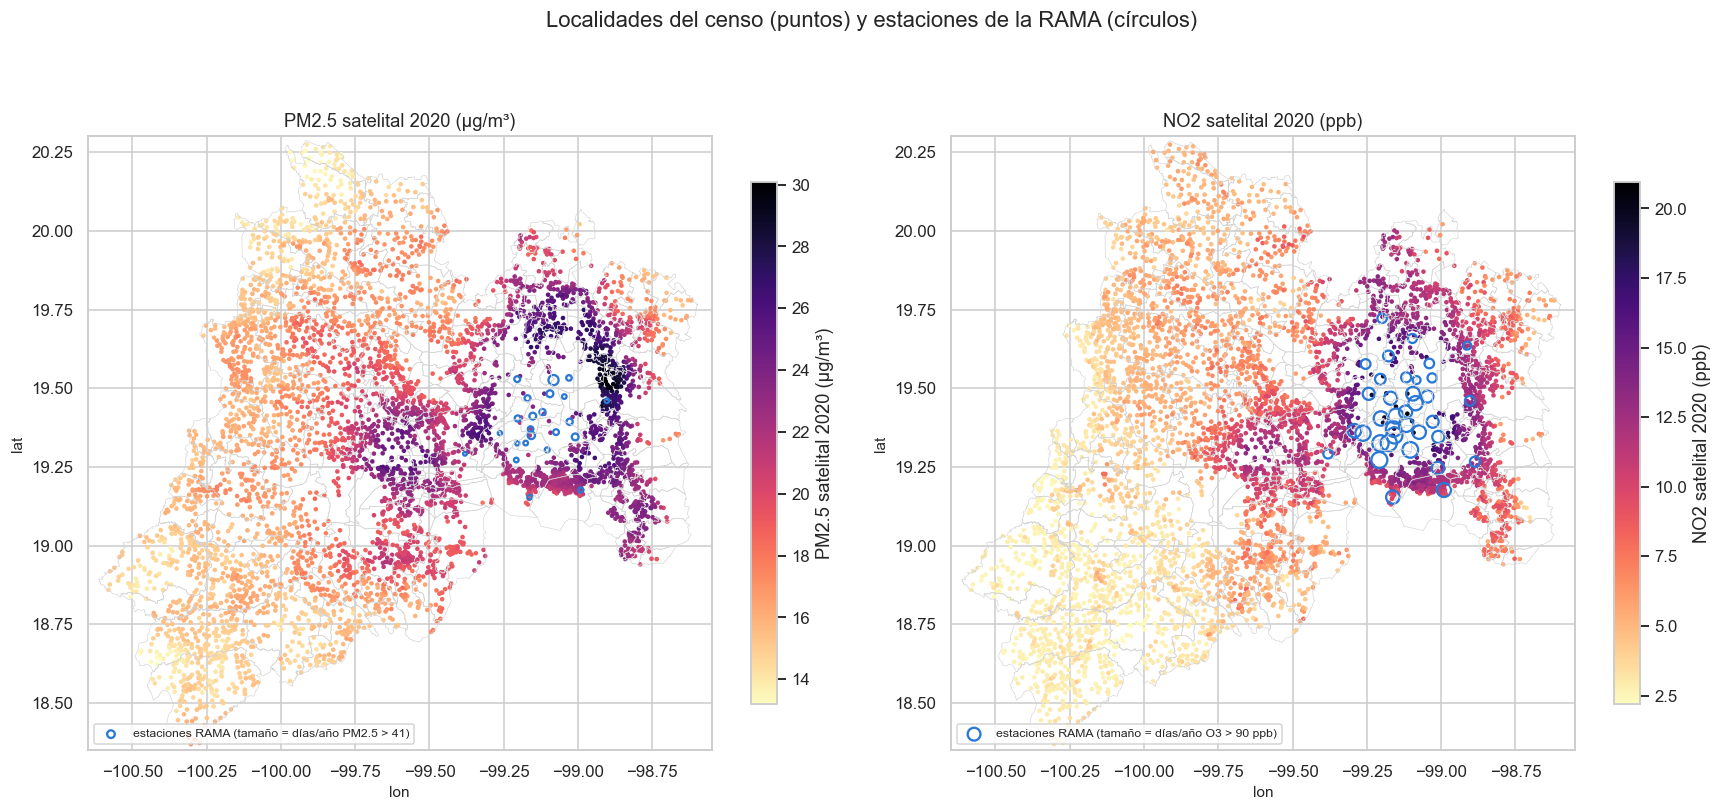

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
for ax, (col, titulo, columna_est, titulo_est) in zip(axes, [
        ("pm25_sat", "PM2.5 satelital 2020 (µg/m³)", "pm25_dias_sobre_por_año", "días/año PM2.5 > 41"),
        ("no2_sat", "NO2 satelital 2020 (ppb)", "o3_dias_sobre_por_año", "días/año O3 > 90 ppb")]):
    municipios.boundary.plot(ax=ax, color="lightgrey", lw=0.4)
    s = ax.scatter(loc.lon, loc.lat, c=loc[col], cmap="magma_r", s=4)
    plt.colorbar(s, ax=ax, shrink=0.7, label=titulo)
    e = est.dropna(subset=[columna_est])
    ax.scatter(e.longitud, e.latitud, s=e[columna_est] / 1.5 + 5, facecolors="none", edgecolors=COLOR["PM2.5"], lw=1.5,
               label=f"estaciones RAMA (tamaño = {titulo_est})")
    ax.set(xlim=(-100.65, -98.55), ylim=(18.35, 20.3), title=titulo, xlabel="lon", ylabel="lat")
    ax.legend(loc="lower left", fontsize=8)
fig.suptitle("Localidades del censo (puntos) y estaciones de la RAMA (círculos)", y=1.0)
fig.tight_layout()
guardar(fig, "mapa_localidades_estaciones")
plt.show()

- **Hay un gradiente norte-sur opuesto para los dos contaminantes.** Las estaciones del norte tienen más PM2.5 (Spearman entre latitud y PM2.5 = 0.61; Xalostoc tiene 59 días al año sobre la norma). Las del sur y suroeste tienen más días de ozono (latitud vs. días de O3: −0.62): Pedregal, el Centro de Ciencias de la Atmósfera y Coyoacán pasan de 159 días al año, y Acolman y Xalostoc tienen 32.
- La explicación física es conocida: los precursores se emiten en el centro y norte, el viento los lleva hacia el sur y, durante la tarde, se convierten en ozono. Quien vive en el sur respira el ozono que se formó con emisiones del norte.
- El NO2 satelital se concentra en el centro y norte de la ciudad, que es justo donde hay más tráfico e industria.

### 7.15 Exposición según nivel socioeconómico

/var/folders/v6/02p113jx7f7f1z845lg5j6m00000gn/T/ipykernel_47498/460796401.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  urb["q_escolaridad"] = urb.groupby("NOM_ENT", group_keys=False).apply(lambda g: quintil_pond(g.GRAPROES, g.POBTOT))
/var/folders/v6/02p113jx7f7f1z845lg5j6m00000gn/T/ipykernel_47498/460796401.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"escolaridad (años)":

escolaridad (años)  PM2.5 sat  NO2 sat  % viv. con auto  días O3 > NOM  población
NOM_ENT          q_escolaridad                                                                                   
Ciudad de México Q1                            9.9       23.3     12.4             39.7          109.4   269225.0
                 Q2                           10.6       23.4     18.1             40.3          118.9  2867867.0
                 Q3                           11.2       23.2     18.9             45.2          117.9  1932354.0
                 Q4                           11.7       23.2     18.2             49.2          125.8  2067232.0
                 Q5                           13.0       22.0     19.1             53.9          143.6  2008954.0
México           Q1                            8.7       23.4     11.9             30.9           71.4  2953429.0
                 Q2                            9.9       24.0     12.8             38.6           58.7  2793483.0
                 Q3                           10.2       24.3     15.7             41.6           51.2  2526443.0
                 Q4                           10.7       23.9     17.5             43.2           77.2  3195927.0
                 Q5                           11.7       24.9     14.4             56.9           63.4  3380293.0

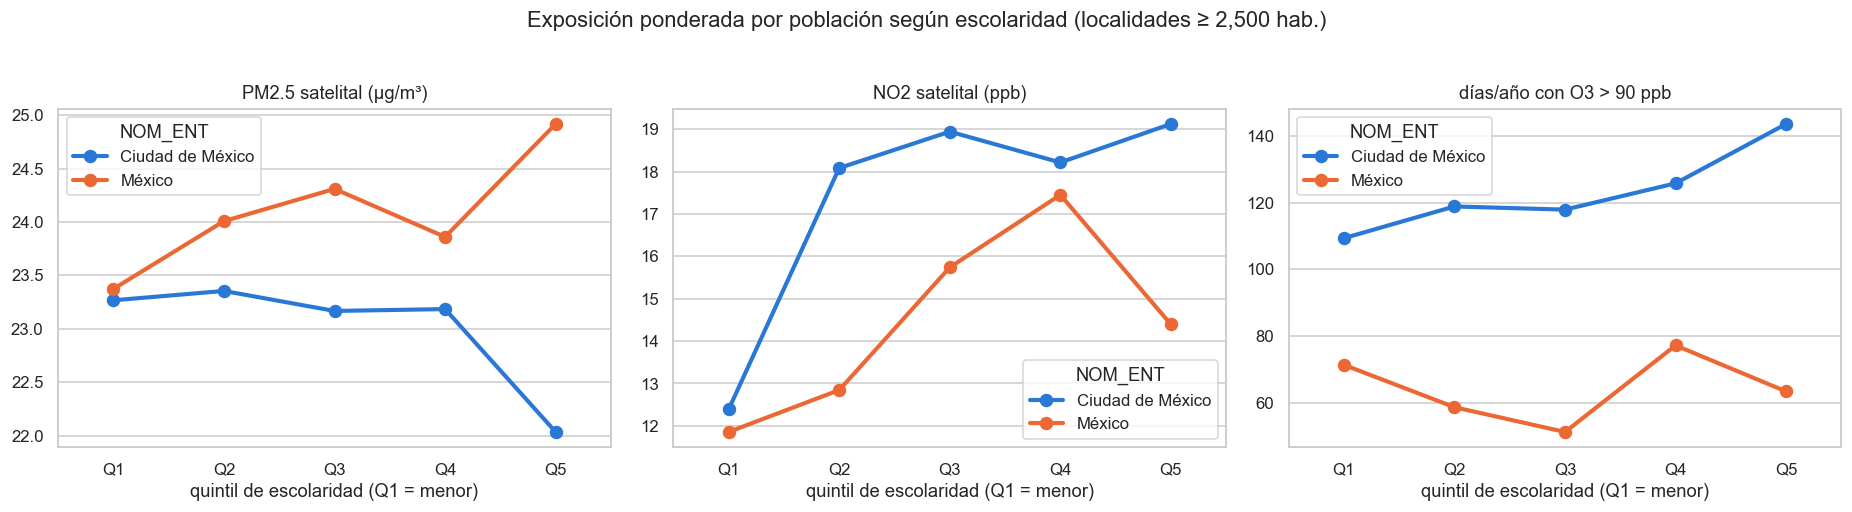

In [29]:
# Gradiente socioeconómico (análisis del EDA anterior, con quintiles ponderados por población)
def quintil_pond(x, w):
    orden = x.sort_values().index
    acum = w.loc[orden].cumsum() / w.loc[orden].sum()
    return pd.cut(acum, [0, .2, .4, .6, .8, 1.0001], labels=["Q1", "Q2", "Q3", "Q4", "Q5"]).reindex(x.index)

urb = loc[(loc.POBTOT >= 2500)].dropna(subset=["GRAPROES", "pm25_sat", "no2_sat"]).copy()
urb["q_escolaridad"] = urb.groupby("NOM_ENT", group_keys=False).apply(lambda g: quintil_pond(g.GRAPROES, g.POBTOT))
tabla_socio = (urb.groupby(["NOM_ENT", "q_escolaridad"], observed=True)
                  .apply(lambda g: pd.Series({"escolaridad (años)": media_pond(g.GRAPROES, g.POBTOT),
                                              "PM2.5 sat": media_pond(g.pm25_sat, g.POBTOT),
                                              "NO2 sat": media_pond(g.no2_sat, g.POBTOT),
                                              "% viv. con auto": media_pond(g.pct_viv_auto, g.POBTOT),
                                              "días O3 > NOM": media_pond(g.o3_dias_sobre_nom, g.POBTOT),
                                              "población": g.POBTOT.sum()})))
display(tabla_socio.round(1))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
t = tabla_socio.reset_index()
for ax, col, etiqueta in zip(axes, ["PM2.5 sat", "NO2 sat", "días O3 > NOM"],
                             ["PM2.5 satelital (µg/m³)", "NO2 satelital (ppb)", "días/año con O3 > 90 ppb"]):
    sns.pointplot(data=t, x="q_escolaridad", y=col, hue="NOM_ENT", ax=ax, palette=[COLOR["PM2.5"], COLOR["O3"]])
    ax.set(title=etiqueta, xlabel="quintil de escolaridad (Q1 = menor)", ylabel="")
fig.suptitle("Exposición ponderada por población según escolaridad (localidades ≥ 2,500 hab.)", y=1.03)
fig.tight_layout()
guardar(fig, "exposicion_escolaridad")
plt.show()

Los quintiles se definen ponderando por población (cada uno tiene ~20% de las personas).

- **CDMX:** el ozono **aumenta** con la escolaridad: el quintil más escolarizado vive con 144 días al año sobre la norma, contra 109 del menos escolarizado. Es el gradiente norte-sur: las alcaldías del sur tienen mayor escolaridad y más ozono. El NO2 también sube con la escolaridad (12.4 → 19.1 ppb).
- **Estado de México:** el PM2.5 y el NO2 satelitales suben con la escolaridad hasta el cuarto quintil (NO2 de 11.9 a 17.4 ppb), porque las localidades más escolarizadas son las urbanas y conurbadas. Las localidades rurales tienen menos escolaridad y menos contaminación.
- **Limitación:** en la CDMX nueve alcaldías son una sola localidad gigante en el censo, así que los quintiles de la CDMX tienen poco detalle. El análisis por AGEB del EDA anterior (Parte B de ese notebook) es la forma de afinarlo.

## 8. Conclusiones

1. **Se construyeron dos datasets unidos por las estaciones.** El diario (3,653 días × 37 variables) sale de 24.8 millones de registros horarios del SIMAT con dos formatos de archivo distintos. El de localidades (5,085 × 32) une el censo y el satélite del EDA anterior con la estación RAMA más cercana. Se documentó un problema de calidad que no viene en el archivo (el viento de 2024).
2. **La contaminación en la ZMVM es un problema cotidiano, no ocasional:** el 75% de los días supera la guía de la OMS para PM2.5, y en el 66% de los días alguna estación rebasa la norma de ozono. En abril y mayo esto llega al 90% de los días.
3. **El PM2.5 ha mejorado desde 2020; el ozono no.** Durante el confinamiento, el CO y el NO2 bajaron 30-40%, pero el ozono solo 4.5%.
4. **La meteorología explica gran parte de la variación diaria:** la temperatura, la amplitud térmica, la humedad y el viento son las variables con más relación. Con un modelo lineal simple se explica el 59-66% del ozono y el 54% del PM2.5 en años que el modelo no vio.
5. **Las relaciones no son lineales y las series tienen autocorrelación.** Hay que modelar log(PM2.5), evaluar con partición temporal y probar modelos no lineales.
6. **Al unir el EDA anterior con las estaciones, el satélite de NO2 resulta confiable (ρ = 0.89) y el de PM2.5 no** (ρ = 0.08). Los contrastes espaciales de PM2.5 satelital del EDA anterior deben tomarse con cautela.
7. **Hay un gradiente norte-sur opuesto:** el PM2.5 es mayor en el norte y el ozono en el sur, donde las estaciones pasan de 150 días al año sobre la norma. 4.45 millones de personas, incluidos 733 mil niños y 534 mil adultos mayores, viven cerca de una estación con más de 120 días al año sobre la norma de ozono.
8. **La red de monitoreo deja fuera a casi 60% de la población del Estado de México** (más de 10 millones de personas sin estación a 5 km).

**Siguiente etapa:** regresión polinomial y robusta (Huber, por los eventos extremos), redes neuronales y clasificación de los días que rebasan la norma. Unir las dos partes: usar el modelo diario para estimar los días sobre la norma en las localidades sin estación, con el satélite de NO2 como guía espacial. También agregar la altura de la capa de mezcla y la radiación solar (ERA5) y usar pronósticos meteorológicos en lugar de lo observado, para que el modelo sirva para anticipar.

**Limitaciones:**

- Se usa la meteorología observada del mismo día. Para un pronóstico real habría que usar la meteorología pronosticada.
- El promedio entre estaciones mezcla zonas distintas de la ciudad.
- El número de estaciones cambia con los años.
- Las emisiones no se observan directamente.
- El satélite es de un solo año (2020, con efecto de la pandemia) y las correlaciones con el censo son ecológicas (por localidad), no individuales.